
# Open Jaynes-Cummings Model: Lindblad Master Equation, Decoherence, and Photon Indistinguishability

---

<!-- **A Research-Grade QuTiP Simulation Notebook**

*Topics covered*: Jaynes-Cummings Hamiltonian · Lindblad master equation · Vacuum Rabi oscillations · Cavity photon decay · Atomic spontaneous emission · Phonon pure dephasing (Independent Boson Model) · Charge noise / spectral diffusion · Nuclear-spin Overhauser noise · Wigner function dynamics · Two-time correlation functions · Hong-Ou-Mandel indistinguishability · Strong-coupling phase diagram

--- -->

## Overview

A semiconductor quantum dot (QD) embedded inside a photonic-crystal or micropillar cavity constitutes one of the leading solid-state platforms for deterministic single-photon generation and cavity quantum electrodynamics (cQED).  
Its physics is ideally captured by the **Jaynes-Cummings (JC) model**, which describes a two-level emitter coherently coupled to a single cavity mode with coupling rate $g$.  
In practice, however, the solid-state environment introduces several decoherence channels:

| Noise source | Physical origin | Theoretical handle |
|---|---|---|
| Cavity photon loss | Mirror transmission, scattering | Lindblad operator $\sqrt{\kappa}\,a$ |
| Atomic/QD decay | Spontaneous emission into leaky modes | Lindblad operator $\sqrt{\gamma}\,\sigma_-$ |
| Phonon pure dephasing | LA-phonon–exciton coupling (Independent Boson Model) | Lindblad operator $\sqrt{\gamma_\phi/2}\,\sigma_z$ |
| Charge noise | Fluctuating electrostatic environment | Stochastic $\omega_{\rm QD}(t)$, Lindblad dephasing |
| Nuclear-spin noise | Overhauser field from $\sim10^4$–$10^6$ nuclei | Gaussian distribution over $\omega_{\rm QD}$ |

This notebook builds up the model layer by layer, visualises each physical effect, and finally quantifies photon indistinguishability $\mathcal{M}$ as a function of all relevant parameters.



## 1. Imports and Global Configuration


In [1]:

import numpy as np
import scipy.integrate as integrate
import scipy.signal as signal
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
import qutip as qt
from qutip import (
    basis, destroy, qeye, tensor, mesolve, mcsolve,
    expect, sigmax, sigmay, sigmaz, sigmam, sigmap,
    wigner, coherent, ket2dm, ptrace, fidelity
)
import warnings
warnings.filterwarnings("ignore")

# ── Matplotlib style ──────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif", "Times New Roman"],
    "font.size":         12,
    "axes.labelsize":    13,
    "axes.titlesize":    13,
    "legend.fontsize":   10,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "text.usetex":       False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
CMAP = "RdBu_r"

print(f"QuTiP version : {qt.__version__}")
print(f"NumPy version : {np.__version__}")


QuTiP version : 5.2.3
NumPy version : 2.0.1



---
## 2. The Jaynes-Cummings Hamiltonian

### 2.1 Derivation in the Rotating-Wave Approximation

The full light–matter Hamiltonian (setting $\hbar = 1$) in the dipole approximation is

$$
H = \underbrace{\omega_c\, a^\dagger a}_{\text{cavity}} +
    \underbrace{\frac{\omega_{\rm QD}}{2}\sigma_z}_{\text{two-level system}} +
    \underbrace{g_0\bigl(a + a^\dagger\bigr)\bigl(\sigma_+ + \sigma_-\bigr)}_{\text{dipole coupling}}
$$

After the **rotating-wave approximation** (RWA), which discards counter-rotating terms $a^\dagger\sigma_+$ and $a\,\sigma_-$ (valid when $g_0 \ll \omega_c, \omega_{\rm QD}$), this simplifies to the **Jaynes-Cummings Hamiltonian**:

$$
\boxed{
H_{\rm JC} = \omega_c\, a^\dagger a + \frac{\omega_{\rm QD}}{2}\sigma_z
           + g\bigl(a^\dagger\sigma_- + a\,\sigma_+\bigr)
}
$$

Here:
- $a, a^\dagger$ — photon annihilation / creation operators for the cavity mode
- $\sigma_\pm = (\sigma_x \pm i\sigma_y)/2$ — atomic raising/lowering operators
- $\omega_c$ — cavity resonance frequency
- $\omega_{\rm QD}$ — QD exciton transition frequency
- $g$ — vacuum Rabi coupling rate (proportional to $\sqrt{1/V_{\rm mode}}$, where $V_{\rm mode}$ is the modal volume)
- $\Delta = \omega_{\rm QD} - \omega_c$ — atom–cavity detuning

### 2.2 Dressed States (Polaritons)

In the one-excitation subspace $\{|1,g\rangle,\, |0,e\rangle\}$ the JC Hamiltonian has analytical eigenstates:

$$
|+,n\rangle = \cos\theta_n\,|n,g\rangle + \sin\theta_n\,|n-1,e\rangle, \quad
|-,n\rangle = -\sin\theta_n\,|n,g\rangle + \cos\theta_n\,|n-1,e\rangle
$$

with $\tan(2\theta_n) = 2g\sqrt{n}/\Delta$ and splitting $\Omega_n = \sqrt{4g^2 n + \Delta^2}$ (**vacuum Rabi splitting** at $n=1$, $\Delta=0$: $\Omega_1 = 2g$).

### 2.3 Hilbert Space Truncation

The cavity field is infinite-dimensional.  For numerical work we truncate at Fock number $N_{\rm cav}$, chosen large enough that the probability of occupying state $|N_{\rm cav}\rangle$ remains negligible throughout the simulation.  A safe criterion is $N_{\rm cav} \gtrsim \langle a^\dagger a\rangle_{\rm max} + 5\sqrt{\langle a^\dagger a\rangle_{\rm max}}$.



### 2.4 System Parameters

We parameterise the system using experimentally realistic values for a self-assembled InGaAs QD in a GaAs micropillar cavity.  
All frequencies are in units of $\mu$eV (or equivalently angular frequency in units where $\hbar = 1$, with $1\,\mu{\rm eV} \approx 2\pi \times 241\,{\rm MHz}$).  
Throughout the notebook we work in the **rotating frame** of the cavity drive frequency $\omega_{\rm drive}$, so the effective Hamiltonian reads  
$$H' = (\omega_c - \omega_{\rm drive})\,a^\dagger a + \frac{(\omega_{\rm QD}-\omega_{\rm drive})}{2}\sigma_z + g(a^\dagger\sigma_- + a\,\sigma_+).$$
For zero detuning and resonant drive this removes the fast oscillation and makes numerical integration efficient.


In [2]:

# ════════════════════════════════════════════════════════════
#  SYSTEM PARAMETERS  (all frequencies in μeV, ℏ = 1)
# ════════════════════════════════════════════════════════════

# Cavity / QD resonance (we work in a rotating frame so bare
# frequencies drop out; only the detuning Δ and coupling g matter)
g      = 80.0    # μeV  — vacuum Rabi coupling
kappa  = 20.0    # μeV  — cavity field decay rate (HWHM = kappa/2)
gamma  = 1.0     # μeV  — QD spontaneous emission (non-cavity modes)
Delta  = 0.0     # μeV  — QD–cavity detuning  (omega_QD - omega_c)

# Dephasing / noise rates
gamma_phi_phonon  = 5.0   # μeV  — phonon pure dephasing (T ~ 4 K)
sigma_charge      = 3.0   # μeV  — std-dev of charge-noise freq. fluctuations
sigma_nuclear     = 1.0   # μeV  — Overhauser field std-dev (rms linewidth)

# Fock-space truncation
N_cav = 10   # number of Fock states (0 … N_cav-1)

# ── Composite operators ───────────────────────────────────────
I_c   = qeye(N_cav)          # identity on cavity
I_a   = qeye(2)              # identity on atom
a     = tensor(destroy(N_cav), I_a)       # cavity annihilation
a_dag = a.dag()
sm    = tensor(I_c, sigmam())             # atomic lowering
sp    = sm.dag()                          # atomic raising
sz    = tensor(I_c, sigmaz())             # atomic inversion
sx    = tensor(I_c, sigmax())

# ── Jaynes-Cummings Hamiltonian (rotating frame, Δ = 0 default) ──
def make_H_JC(delta=Delta, g_val=g):
    '''Return JC Hamiltonian for given detuning and coupling.'''
    return delta * sp * sm + g_val * (a_dag * sm + a * sp)

H_JC = make_H_JC()

# ── Dressed-state energies (analytical) ──────────────────────
def dressed_energies(n, delta=0.0, g_val=g):
    Omega_n = np.sqrt(4 * g_val**2 * n + delta**2)
    E_plus  =  0.5 * Omega_n
    E_minus = -0.5 * Omega_n
    return E_plus, E_minus

E_p1, E_m1 = dressed_energies(1)
print(f"Vacuum Rabi splitting  2g = {2*g:.1f} μeV")
print(f"Dressed state E+,1    = {E_p1:.2f} μeV,   E-,1 = {E_m1:.2f} μeV")
print(f"Strong-coupling cond. g/kappa = {g/kappa:.2f}  (>1 = strong coupling)")
print(f"Cooperativity  C = g^2/(kappa*gamma) = {g**2/(kappa*gamma):.1f}")


Vacuum Rabi splitting  2g = 160.0 μeV
Dressed state E+,1    = 80.00 μeV,   E-,1 = -80.00 μeV
Strong-coupling cond. g/kappa = 4.00  (>1 = strong coupling)
Cooperativity  C = g^2/(kappa*gamma) = 320.0



---
## 3. The Lindblad Master Equation

### 3.1 Derivation via Born-Markov-Secular Approximation

Tracing out the environmental degrees of freedom — under the assumptions of  
(i) weak system–bath coupling (**Born approximation**),  
(ii) short bath correlation time (**Markov approximation**), and  
(iii) well-separated system transition frequencies (**secular/rotating-wave approximation**) —  
yields the **Gorini-Kossakowski-Sudarshan-Lindblad (GKSL) master equation**:

$$
\dot{\rho} = -\frac{i}{\hbar}\bigl[H, \rho\bigr]
           + \sum_n \left(
               L_n\,\rho\,L_n^\dagger
             - \frac{1}{2}\bigl\{L_n^\dagger L_n,\, \rho\bigr\}
             \right)
$$

The superoperator $\mathcal{L}[\rho]$ on the right-hand side is the **Liouvillian**.  
The $L_n$ are **jump (collapse) operators**, each encoding a distinct decoherence channel.

### 3.2 Physical Collapse Operators

| Channel | $L_n$ | Rate |
|---|---|---|
| Cavity photon loss | $\sqrt{\kappa}\,a$ | $\kappa$ (cavity linewidth) |
| QD spontaneous emission | $\sqrt{\gamma}\,\sigma_-$ | $\gamma = 1/T_1$ |
| Pure dephasing (phonon / charge / nuclear) | $\sqrt{\gamma_\phi/2}\,\sigma_z$ | $\gamma_\phi$ |

**Pure dephasing** ($\sigma_z$ collapse) destroys off-diagonal coherences $\rho_{eg}$ without changing populations:
$$
\frac{d\rho_{eg}}{dt}\bigg|_{\rm deph} = -\frac{\gamma_\phi}{2}\rho_{eg}
\quad\Rightarrow\quad
T_2 = \frac{1}{\gamma/2 + \gamma_\phi/2}, \quad T_2 \le 2T_1
$$

The **total optical linewidth** (FWHM) is therefore  
$$\Gamma_{\rm opt} = \frac{1}{T_2} = \frac{\gamma}{2} + \gamma_\phi$$
and the transform-limited linewidth is $\Gamma_{\rm TL} = \gamma/2$.  
Indistinguishability degrades as $\mathcal{M} \approx \Gamma_{\rm TL}/\Gamma_{\rm opt}$.

### 3.3 Quantum Trajectory Interpretation

The master equation is the ensemble average over stochastic **quantum trajectories** (Monte Carlo wave-function method).  Each trajectory evolves continuously under a non-Hermitian effective Hamiltonian  
$$
H_{\rm eff} = H - \frac{i}{2}\sum_n L_n^\dagger L_n
$$  
with sudden quantum jumps $$|\psi\rangle \to L_n|\psi\rangle/\|L_n|\psi\rangle\|$$ occurring at random times.


In [3]:

# ════════════════════════════════════════════════════════════
#  SECTION 3 CODE: Build collapse operators
# ════════════════════════════════════════════════════════════
# This cell constructs the Lindblad collapse operators for the
# three primary decoherence channels in the QD-cavity system.

def make_collapse_ops(kap=kappa, gam=gamma, gam_phi=0.0):
    '''
    Parameters
    ----------
    kap      : cavity decay rate  kappa
    gam      : QD spontaneous emission rate  gamma
    gam_phi  : pure dephasing rate  gamma_phi

    Returns
    -------
    list of Qobj collapse operators
    '''
    c_ops = []
    if kap   > 0: c_ops.append(np.sqrt(kap)       * a)      # cavity decay
    if gam   > 0: c_ops.append(np.sqrt(gam)       * sm)     # QD emission
    if gam_phi > 0: c_ops.append(np.sqrt(gam_phi/2) * sz)   # pure dephasing
    return c_ops

# Default: cavity + QD decay only (no dephasing yet)
c_ops_base = make_collapse_ops()

# Print Liouvillian spectrum to check for real eigenvalues (stability)
L_super = qt.liouvillian(H_JC, c_ops_base)
print(f"Liouvillian superoperator dimensions: {L_super.dims}")
print(f"Number of collapse operators (base): {len(c_ops_base)}")

# Effective non-Hermitian Hamiltonian for quantum-trajectory interpretation
H_eff = H_JC - 0.5j * sum(op.dag() * op for op in c_ops_base)
print(f"\nH_eff is Hermitian: {H_eff.isherm}")
print(f"Cavity Fock truncation N_cav = {N_cav}")


Liouvillian superoperator dimensions: [[[10, 2], [10, 2]], [[10, 2], [10, 2]]]
Number of collapse operators (base): 2

H_eff is Hermitian: False
Cavity Fock truncation N_cav = 10



---
## 4. Vacuum Rabi Oscillations — Coherent Evolution and Decay

### Theory

Starting with one excitation in the cavity ($|1,g\rangle$) and the QD in the ground state, the JC model predicts sinusoidal exchange of excitation between the field and the emitter at the **vacuum Rabi frequency** $\Omega_R = 2g$.  
Decoherence damps these oscillations: if $g > (\kappa + \gamma)/4$ the system is in the **strong-coupling regime** where at least one full Rabi oscillation occurs before the excitation decays.

Observable quantities:
- $\langle a^\dagger a\rangle(t)$ — mean intracavity photon number
- $\langle\sigma_+\sigma_-\rangle(t)$ — QD excited-state population
- $\langle\sigma_z\rangle(t)$ — Bloch vector $z$-component


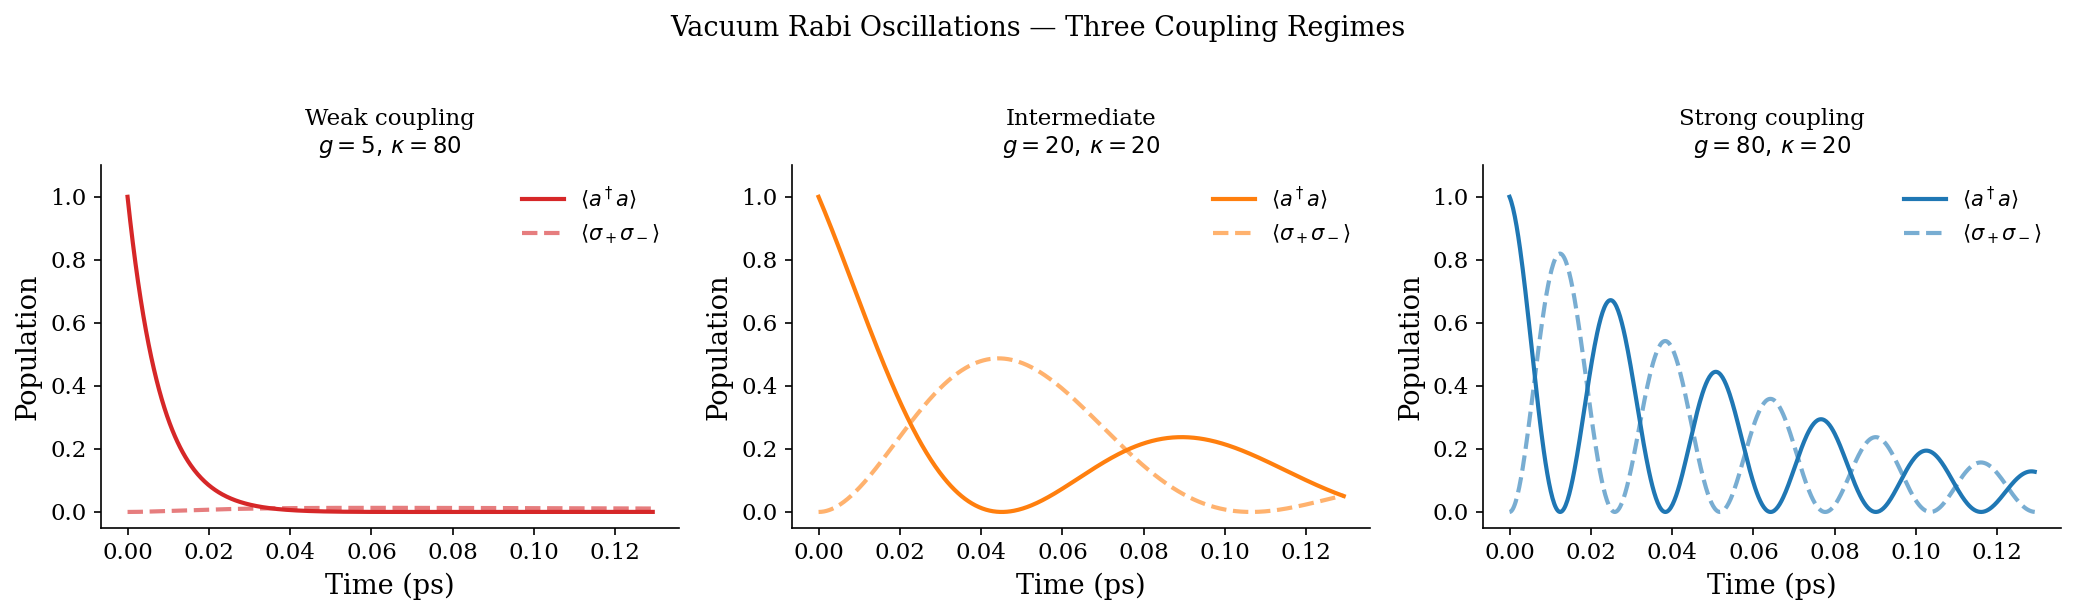

Figure saved → fig1_vacuum_rabi.pdf


In [4]:

# ════════════════════════════════════════════════════════════
#  SECTION 4: Vacuum Rabi Oscillations
# ════════════════════════════════════════════════════════════
# We solve the Lindblad master equation for the initial state
# |psi_0> = |1>_cavity otimes |g>_atom, i.e., one photon in the cavity
# and the QD in the ground state.  The excitation coherently
# oscillates at 2g before being irreversibly lost through kappa and gamma.

# Time axis: several Rabi periods
t_max = 5 * np.pi / g         # ~5 Rabi half-periods
tlist = np.linspace(0, t_max, 600)

# Initial state: |1, g>
psi0 = tensor(basis(N_cav, 1), basis(2, 1))  # |1>_cav otimes |g>_atom
rho0 = ket2dm(psi0)

# Expectation value operators
n_cav_op  = a_dag * a          # intracavity photon number
n_atom_op = sp * sm            # QD excited-state population

# ── Solve for three coupling regimes ──────────────────────────────────────────
regimes = {
    "Weak coupling\n$g=5,\\,\\kappa=80$":   (5.0,  80.0, 1.0),
    "Intermediate\n$g=20,\\,\\kappa=20$":   (20.0, 20.0, 1.0),
    "Strong coupling\n$g=80,\\,\\kappa=20$": (80.0, 20.0, 1.0),
}

results = {}
for label, (g_val, kap_val, gam_val) in regimes.items():
    H_r   = make_H_JC(g_val=g_val)
    c_r   = make_collapse_ops(kap=kap_val, gam=gam_val)
    res   = mesolve(H_r, rho0, tlist,
                    c_ops=c_r,
                    e_ops=[n_cav_op, n_atom_op])
    results[label] = res

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = ["#d62728", "#ff7f0e", "#1f77b4"]

for ax, (label, res), col in zip(axes, results.items(), colors):
    n_ph  = np.array(res.expect[0])
    n_at  = np.array(res.expect[1])
    t_ns  = tlist * 0.658  # convert muev*t -> ps  (hbar/muev ~ 0.658 ps)
    ax.plot(t_ns, n_ph, lw=2,   color=col,    label=r"$\langle a^\dagger a\rangle$")
    ax.plot(t_ns, n_at, lw=2, ls="--", color=col, alpha=0.6,
            label=r"$\langle\sigma_+\sigma_-\rangle$")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("Population")
    ax.legend(loc="upper right", frameon=False)
    ax.set_ylim(-0.05, 1.1)

fig.suptitle("Vacuum Rabi Oscillations — Three Coupling Regimes", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig1_vacuum_rabi.pdf", bbox_inches="tight")
plt.show()
print("Figure saved → fig1_vacuum_rabi.pdf")



### Figure 1 — Vacuum Rabi Oscillations in Three Regimes

**Left panel (weak coupling, $g \ll \kappa$):** The excitation simply decays exponentially out of the cavity; no oscillation is visible.  This is the Purcell regime: the cavity enhances the emission rate but the photon is lost before a round-trip can occur.

**Middle panel (intermediate):** A single, heavily damped oscillation is visible before the excitation decays.  The system is near the crossover $g \approx \kappa/4$.

**Right panel (strong coupling, $g \gg \kappa, \gamma$):** Clear coherent Rabi oscillations persist over multiple periods, with the cavity and QD periodically exchanging the single quantum of excitation.  The envelope decays at rate $(\kappa + \gamma)/4$.  This regime is required for deterministic photon–photon gates and for the generation of highly indistinguishable photons via the Purcell effect.

The dashed lines show the QD excited-state population $\langle\sigma_+\sigma_-\rangle$, which is $\pi$-phase shifted from the intracavity photon number, confirming the coherent exchange.



---
## 5. Wigner Function Dynamics of the Cavity Field

### Theory

The **Wigner function** $W(\alpha)$ is a quasi-probability distribution over the complex phase space $\alpha = x + ip$:

$$W(\alpha) = \frac{2}{\pi}\,\mathrm{Tr}\bigl[\rho_c\, D(\alpha)\,(-1)^{a^\dagger a}\, D^\dagger(\alpha)\bigr]$$

where $D(\alpha) = e^{\alpha a^\dagger - \alpha^* a}$ is the displacement operator and $\rho_c = \mathrm{Tr}_{\rm atom}[\rho]$ is the reduced cavity state.

- A **Gaussian** $W$ centred at $\alpha \ne 0$ indicates a coherent state.
- A **ring** (positive at $|\alpha|>0$) indicates a Fock (photon-number) state.
- **Negativity** of $W$ is a signature of non-classical (quantum) light.

Tracking $W(\alpha, t)$ reveals how the quantum state of the field evolves under the JC interaction and decoheres due to cavity loss.


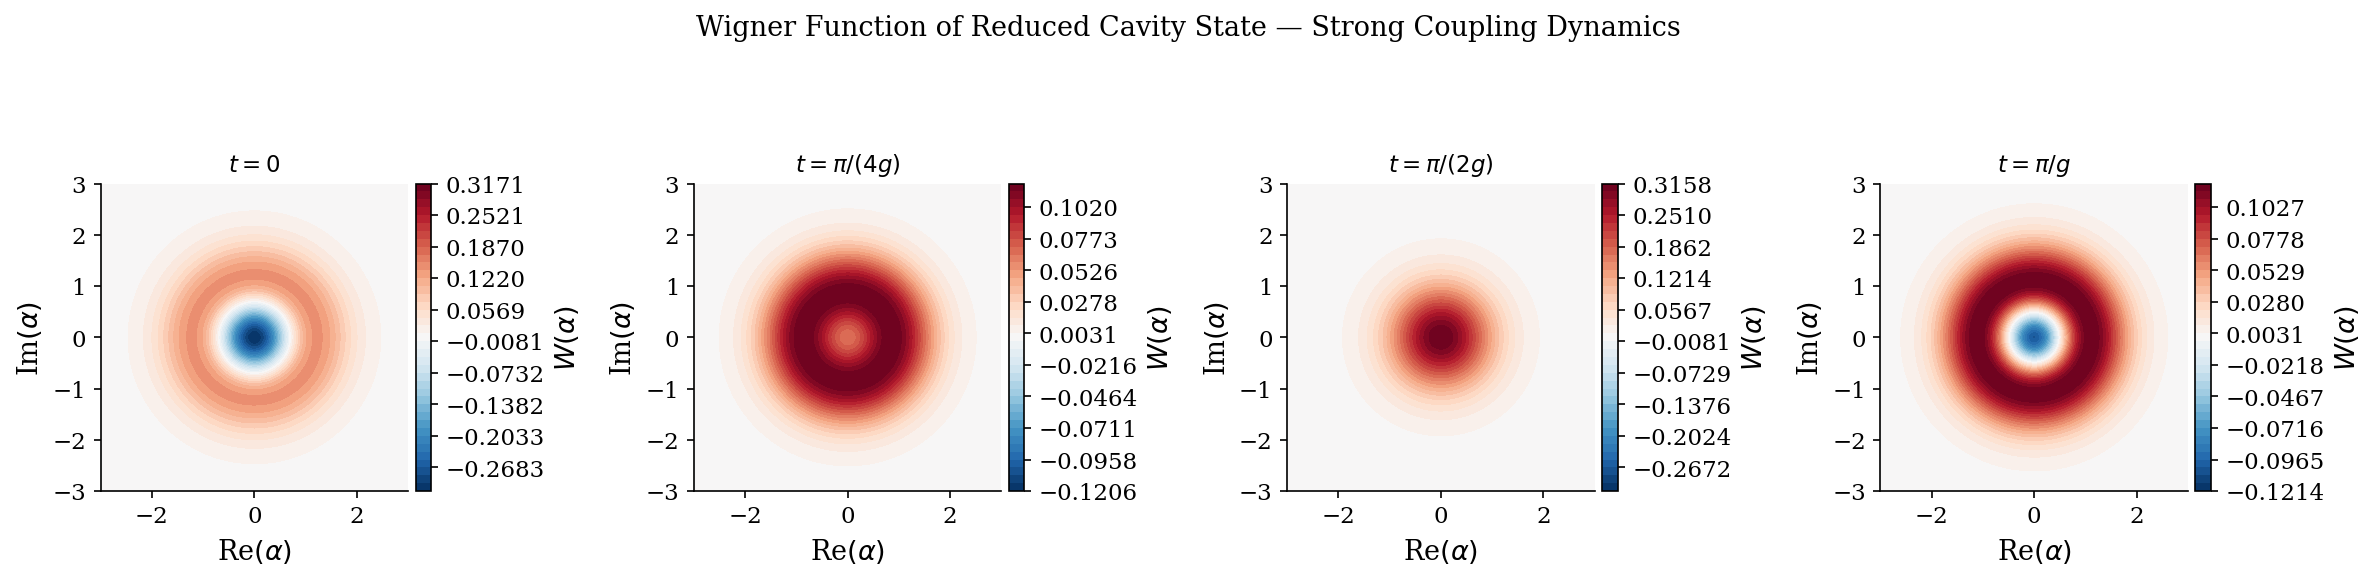

Figure saved → fig2_wigner.pdf


In [5]:

# ════════════════════════════════════════════════════════════
#  SECTION 5: Wigner Function Snapshots
# ════════════════════════════════════════════════════════════
# We evolve the system in the strong-coupling regime and compute
# the Wigner function of the REDUCED CAVITY STATE at selected times.
# ptrace(rho, 0) traces out the atom (index 1) to get ρ_cavity.

snap_times = [0,
              0.25 * np.pi / g,   # quarter Rabi period
              0.5  * np.pi / g,   # half Rabi period
              np.pi / g]          # full Rabi period

# Use store_states=True to retrieve full density matrices
res_wig = mesolve(H_JC, rho0, np.linspace(0, np.pi/g, 200),
                  c_ops=c_ops_base,
                  options={"store_states": True})

# Phase-space grid
xvec = np.linspace(-3, 3, 120)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
snap_indices = [0, 50, 100, 199]
snap_labels  = [r"$t=0$",
                r"$t=\pi/(4g)$",
                r"$t=\pi/(2g)$",
                r"$t=\pi/g$"]

for ax, idx, lbl in zip(axes, snap_indices, snap_labels):
    rho_full = res_wig.states[idx]
    rho_cav  = ptrace(rho_full, 0)      # partial trace over atom (subsystem 1)
    W = wigner(rho_cav, xvec, xvec)
    wmax = np.max(np.abs(W))
    im = ax.contourf(xvec, xvec, W,
                     levels=np.linspace(-wmax, wmax, 40),
                     cmap=CMAP)
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel(r"Re$(\alpha)$")
    ax.set_ylabel(r"Im$(\alpha)$")
    ax.set_aspect("equal")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax, label=r"$W(\alpha)$")

fig.suptitle("Wigner Function of Reduced Cavity State — Strong Coupling Dynamics",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig2_wigner.pdf", bbox_inches="tight")
plt.show()
print("Figure saved → fig2_wigner.pdf")



### Figure 2 — Wigner Function Snapshots

- **$t=0$**: The cavity starts in Fock state $|1\rangle$.  The Wigner function shows the characteristic ring with a **negative** central lobe at $\alpha=0$, confirming non-classical light.
- **$t=\pi/(4g)$**: Partial transfer to the QD; the cavity is now in a superposition of $|0\rangle$ and $|1\rangle$.  The ring structure begins to distort.
- **$t=\pi/(2g)$**: Half Rabi period — the excitation is mostly in the QD ($\langle a^\dagger a\rangle \approx 0$).  The cavity is nearly in the vacuum $|0\rangle$, so $W$ collapses toward a Gaussian at the origin.
- **$t=\pi/g$**: Full Rabi period — the excitation has returned to the cavity (partially, due to damping from $\kappa$).  The Wigner function partially recovers the ring, but with reduced negativity due to photon loss.

The persistence of Wigner negativity in the right panel demonstrates that the system remains in a non-classical state even after one full Rabi cycle, a hallmark of the strong-coupling regime.



---
## 6. Phonon Pure Dephasing — The Independent Boson Model

### 6.1 Physical Mechanism

In self-assembled QDs, longitudinal-acoustic (LA) phonons couple to the exciton via **deformation potential** interaction.  The independent boson model (IBM) treats the lattice as a bath of uncoupled harmonic oscillators linearly coupled to the QD population:

$$H_{\rm IBM} = \frac{\omega_0}{2}\sigma_z + \sum_k \omega_k b_k^\dagger b_k + \sigma_z \sum_k \lambda_k(b_k + b_k^\dagger)$$

where $b_k, b_k^\dagger$ are phonon operators and $\lambda_k$ is the coupling strength.

### 6.2 Spectral Density and Pure Dephasing Rate

After tracing out the phonon bath in the Born-Markov approximation, one obtains a **pure dephasing** contribution:

$$\gamma_\phi(T) = 2\int_0^\infty d\omega\, J(\omega)\,\coth\!\left(\frac{\omega}{2k_B T}\right)$$

where the **phonon spectral density** for a QD is well approximated by a super-Ohmic form:

$$J(\omega) = \alpha_p\,\omega^3\,e^{-\omega^2/\omega_c^2}$$

with $\alpha_p$ the deformation-potential constant and $\omega_c$ a cutoff related to the QD confinement size.  At low temperatures $\gamma_\phi \propto T^3$ (phonon-dominated), while at high $T$ it grows linearly.

### 6.3 Lindblad Representation

The phonon pure dephasing enters the master equation as:

$$\mathcal{D}[\sqrt{\gamma_\phi/2}\,\sigma_z]\rho = \frac{\gamma_\phi}{2}\bigl(\sigma_z\rho\sigma_z - \rho\bigr)$$

which damps only the off-diagonal elements: $\dot{\rho}_{eg} = -\tfrac{\gamma_\phi}{2}\rho_{eg}$.

### 6.4 Effect on Indistinguishability

Phonon dephasing reduces photon indistinguishability to:

$$\mathcal{M} \approx \frac{\Gamma_{\rm TL}}{\Gamma_{\rm TL} + \gamma_\phi/2} = \frac{1/T_1}{1/T_1 + \gamma_\phi/2}$$

demonstrating that faster spontaneous emission (e.g.\ via the Purcell effect, $1/T_1 \to F_P/T_1^0$) improves $\mathcal{M}$.


Phonon pure dephasing at T=4 K:   gamma_phi = 0.03 μeV
Phonon pure dephasing at T=20 K:  gamma_phi = 0.03 μeV


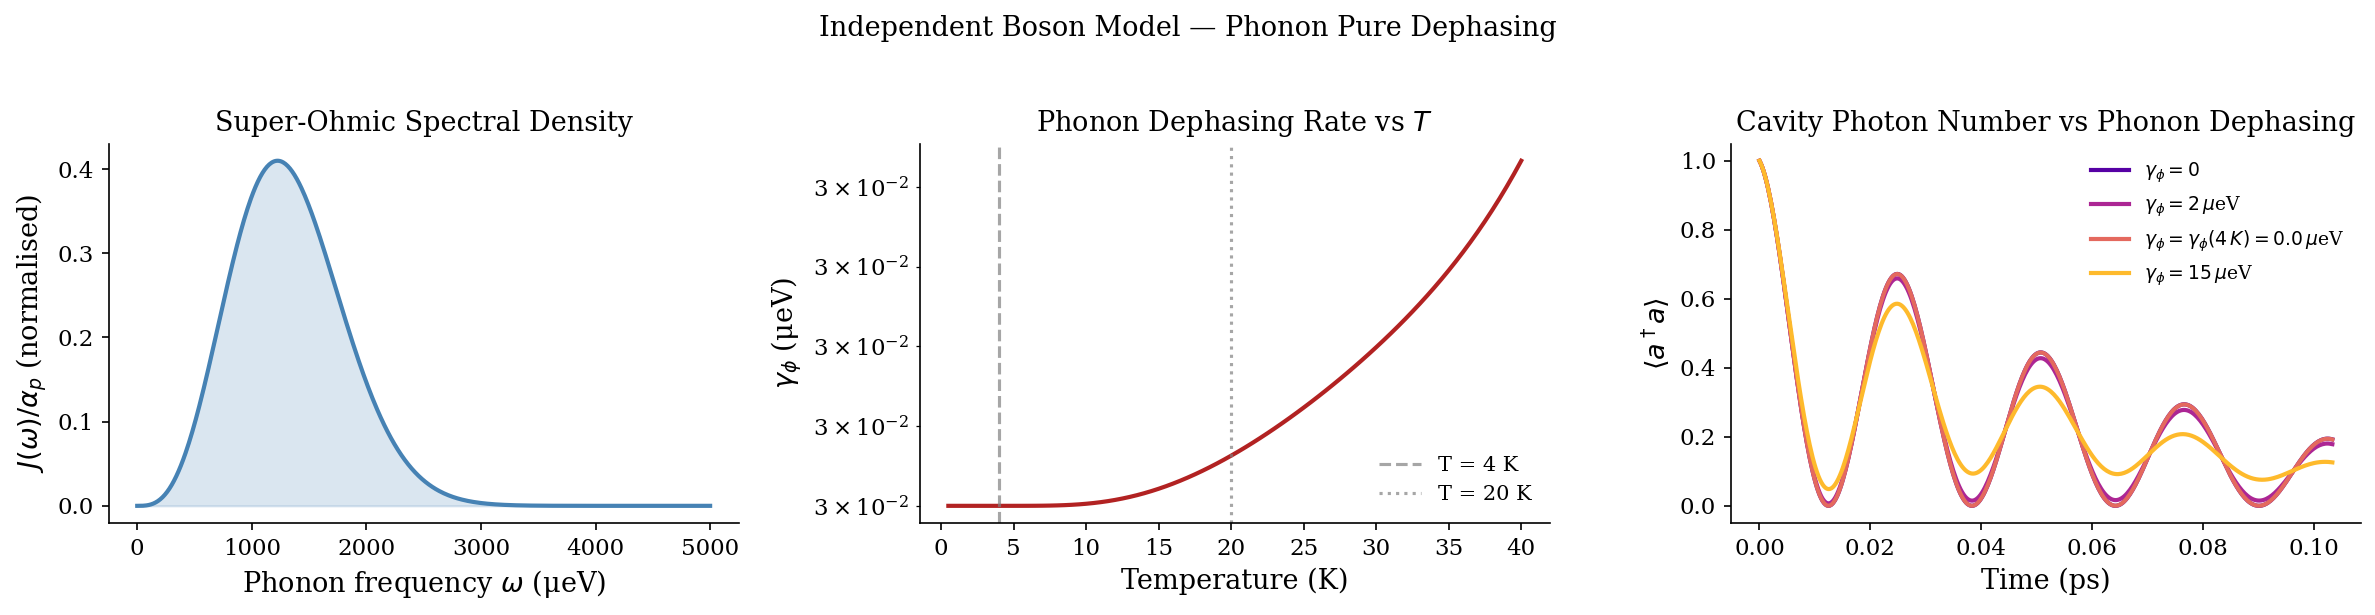

Figure saved → fig3_phonon_dephasing.pdf


In [6]:

# ════════════════════════════════════════════════════════════
#  SECTION 6: Phonon Pure Dephasing
#  — Spectral density, temperature dependence, and
#    impact on optical coherence (T2)
# ════════════════════════════════════════════════════════════

# ── 6a. Phonon spectral density (super-Ohmic) ────────────────
alpha_p  = 0.03e-3   # meV^3  (deformation potential constant, typ. InGaAs)
omega_c  = 1.0       # meV   (phonon cutoff ~ confinement energy)
k_B      = 0.0862e-3 # meV/K (Boltzmann constant)

omega_arr = np.linspace(0, 5 * omega_c, 500)   # phonon freq. grid (meV)

def J_phonon(omega, alpha=alpha_p, wc=omega_c):
    '''Super-Ohmic spectral density J(omega) = alpha * omega^3 * exp(-omega^2/wc^2).'''
    return alpha * omega**3 * np.exp(-(omega/wc)**2)

def gamma_phi_phonon(T, alpha=alpha_p, wc=omega_c):
    '''
    Temperature-dependent pure dephasing rate from phonons.
    gamma_phi(T) = 2 * int J(omega) * coth(omega / (2*kB*T)) domega  [meV]
    '''
    if T < 0.1:
        return 1e-6  # avoid div/0
    integrand = lambda w: 2 * J_phonon(w, alpha, wc) / np.tanh(w / (2 * k_B * T))
    val, _ = integrate.quad(integrand, 1e-6, 10 * wc, limit=200)
    return val

T_arr    = np.linspace(0.5, 40, 80)    # temperature (K)
gph_arr  = np.array([gamma_phi_phonon(T) for T in T_arr])  # meV

# ── 6b. Impact on Rabi oscillations ───────────────────────────
# Convert phonon dephasing to μeV for consistency with JC parameters
gph_4K = gamma_phi_phonon(4.0) * 1e3  # 4 K → μeV

print(f"Phonon pure dephasing at T=4 K:   gamma_phi = {gph_4K:.2f} μeV")
print(f"Phonon pure dephasing at T=20 K:  gamma_phi = {gamma_phi_phonon(20)*1e3:.2f} μeV")

# Solve master equation for several dephasing rates
deph_vals = [0.0, 2.0, gph_4K, 15.0]   # μeV
deph_labels = [f"$\\gamma_\\phi=0$",
               f"$\\gamma_\\phi=2\\,\\mu$eV",
               f"$\\gamma_\\phi=\\gamma_{{\\phi}}(4\\,K)={gph_4K:.1f}\\,\\mu$eV",
               f"$\\gamma_\\phi=15\\,\\mu$eV"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Panel A: Spectral density ──────────────────────────────────
ax = axes[0]
ax.plot(omega_arr * 1e3, J_phonon(omega_arr) / alpha_p, "steelblue", lw=2)
ax.set_xlabel(r"Phonon frequency $\omega$ (μeV)")
ax.set_ylabel(r"$J(\omega)/\alpha_p$ (normalised)")
ax.set_title("Super-Ohmic Spectral Density")
ax.fill_between(omega_arr * 1e3, J_phonon(omega_arr) / alpha_p, alpha=0.2, color="steelblue")

# -- Panel B: gamma_phi vs temperature ───────────────────────────────
ax = axes[1]
ax.semilogy(T_arr, gph_arr * 1e3, "firebrick", lw=2)
ax.axvline(4,  ls="--", color="gray", alpha=0.7, label="T = 4 K")
ax.axvline(20, ls=":",  color="gray", alpha=0.7, label="T = 20 K")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel(r"$\gamma_\phi$ (μeV)")
ax.set_title(r"Phonon Dephasing Rate vs $T$")
ax.legend(frameon=False)

# ── Panel C: Rabi oscillations vs dephasing ───────────────────
ax = axes[2]
tlist2 = np.linspace(0, 4 * np.pi / g, 400)
cols   = plt.cm.plasma(np.linspace(0.15, 0.85, len(deph_vals)))
for gph_val, lbl, col in zip(deph_vals, deph_labels, cols):
    c_ops_ph = make_collapse_ops(gam_phi=gph_val)
    res_ph   = mesolve(H_JC, rho0, tlist2, c_ops=c_ops_ph,
                       e_ops=[n_cav_op])
    t_ps     = tlist2 * 0.658
    ax.plot(t_ps, np.array(res_ph.expect[0]), lw=2, color=col, label=lbl)
ax.set_xlabel("Time (ps)")
ax.set_ylabel(r"$\langle a^\dagger a \rangle$")
ax.set_title("Cavity Photon Number vs Phonon Dephasing")
ax.legend(frameon=False, fontsize=9)

fig.suptitle("Independent Boson Model — Phonon Pure Dephasing", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig3_phonon_dephasing.pdf", bbox_inches="tight")
plt.show()
print("Figure saved → fig3_phonon_dephasing.pdf")



### Figure 3 — Phonon Pure Dephasing

**Panel A — Spectral Density:** The super-Ohmic form $J(\omega) \propto \omega^3 e^{-\omega^2/\omega_c^2}$ peaks near the phonon cutoff $\omega_c$ (set by the QD confinement length $\ell \sim 10$–$20\,{\rm nm}$ via $\omega_c \sim \hbar v_s / \ell$, where $v_s$ is the sound velocity).  Phonons at $\omega \gg \omega_c$ cannot efficiently couple to the QD because their wavelength is smaller than the dot.

**Panel B — Temperature Dependence:** $\gamma_\phi(T)$ grows rapidly from the vacuum (zero-point) value, following $\propto T^3$ at low $T$ (three-phonon absorption threshold) and approaching a linear dependence at $T \gtrsim 20\,{\rm K}$.  At $T = 4\,{\rm K}$ (standard liquid-helium temperature for QD experiments), the dephasing is already significant compared to $g$ and $\kappa$.

**Panel C — Impact on Rabi Oscillations:** Increasing $\gamma_\phi$ accelerates the collapse of Rabi oscillations.  The oscillation frequency ($2g$) is unchanged — pure dephasing only destroys coherence without shifting energy levels — but the envelope decays exponentially at rate $(\kappa + \gamma)/4 + \gamma_\phi/2$.  At the highest dephasing rate shown, the oscillations are barely distinguishable, illustrating why operating at $T < 10\,{\rm K}$ is critical for photon indistinguishability.



---
## 7. Charge Noise and Spectral Diffusion

### 7.1 Physical Mechanism

In a semiconductor QD, nearby charge traps (at surfaces, interfaces, or defects) stochastically capture and release electrons.  Each charge reconfiguration shifts the QD transition frequency via the quantum-confined Stark effect:

$$\omega_{\rm QD}(t) = \omega_{\rm QD}^{(0)} + \delta\omega(t)$$

where $\delta\omega(t)$ is a random process with:
- **Short-time** (fast fluctuation): appears as a dephasing rate $\gamma_{\rm charge}$ in the Lindblad picture
- **Long-time** (slow drifts): appears as **spectral diffusion** (broadening of the time-averaged lineshape)

### 7.2 Lindblad Approximation for Fast Charge Noise

When $\delta\omega(t)$ fluctuates much faster than the system dynamics (Markov limit), it maps to a Lindblad pure-dephasing channel:

$$L_{\rm charge} = \sqrt{\gamma_{\rm charge}/2}\;\sigma_z, \quad \gamma_{\rm charge} = 2\sigma_\omega^2 / \tau_c$$

where $\sigma_\omega$ is the rms frequency fluctuation and $\tau_c$ is the noise correlation time.

### 7.3 Slow Spectral Diffusion — Inhomogeneous Averaging

For slow noise ($\tau_c \gg 1/\gamma$), the QD transition frequency is effectively static over each photon emission event but drifts between events.  The observed emission spectrum is then an inhomogeneous average:

$$S(\omega) = \int_{-\infty}^{\infty} d(\delta\omega)\, P(\delta\omega)\, S_0(\omega - \delta\omega)$$

where $P(\delta\omega) = \mathcal{N}(0, \sigma_{\rm charge}^2)$ is the Gaussian distribution of frequency shifts and $S_0$ is the transform-limited Lorentzian spectrum.  This convolution yields a **Voigt profile**.


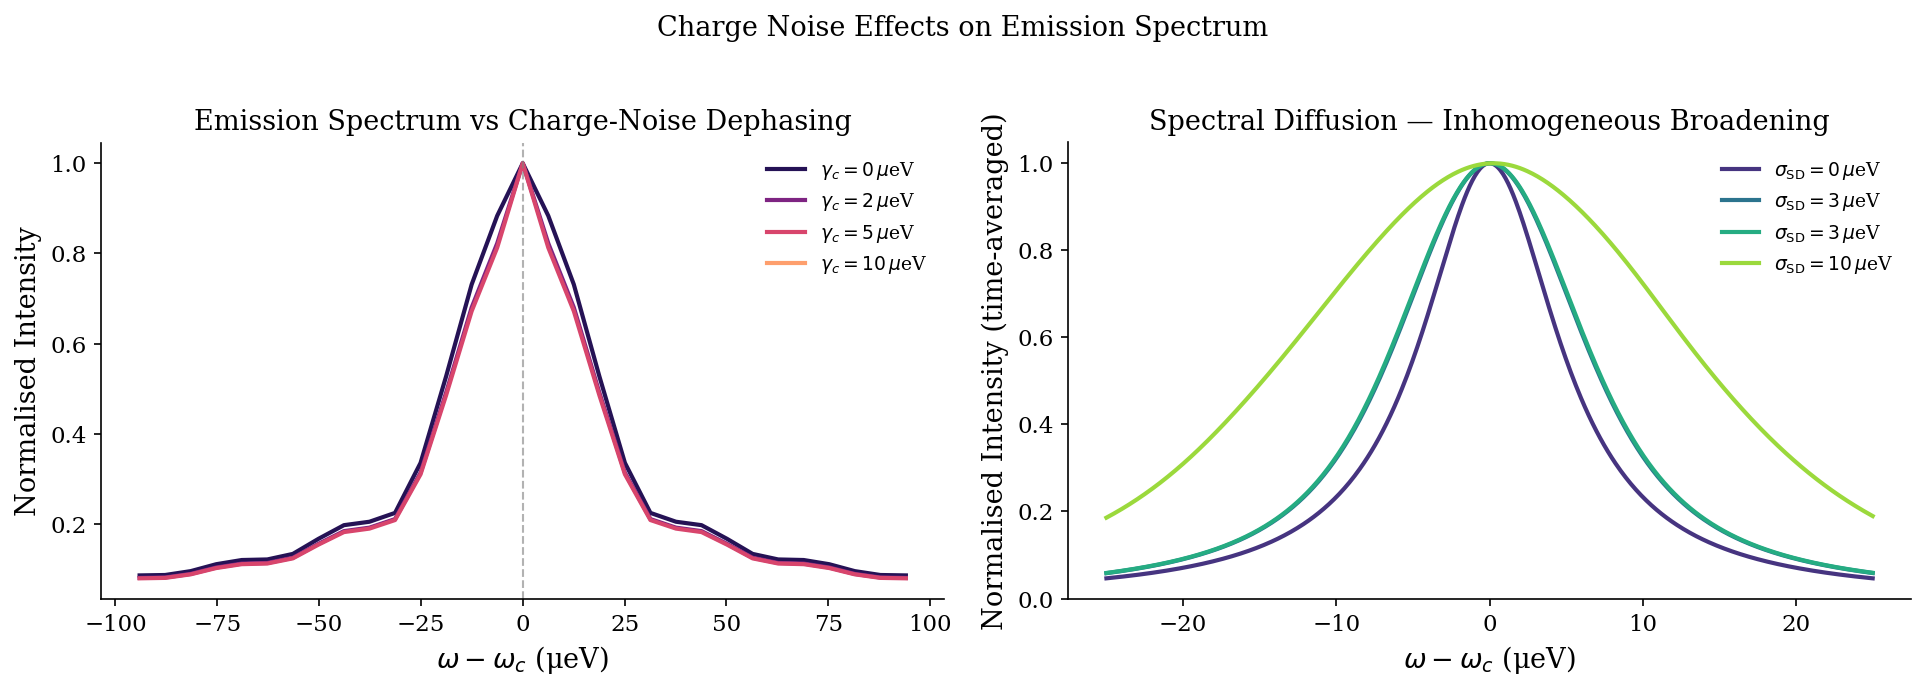

Figure saved → fig4_charge_noise.pdf


In [7]:

# ════════════════════════════════════════════════════════════
#  SECTION 7: Charge Noise / Spectral Diffusion
# ════════════════════════════════════════════════════════════
# We model charge noise in two complementary ways:
#   (a) Fast noise → Lindblad dephasing term  (analytical + ME)
#   (b) Slow spectral diffusion → inhomogeneous Gaussian
#       averaging of the emission spectrum

# ── 7a. Emission spectrum via two-time correlations ──────────
# The emission spectrum S(omega) is the Fourier transform of the
# first-order field correlation g1(tau) = <a_dag(t+tau) a(t)>_ss
# computed via the quantum regression theorem in QuTiP.

tlist_ss   = np.linspace(0, 30 / kappa, 600)   # time to reach steady state
tau_list   = np.linspace(0,  20 / kappa, 500)   # delay times for correlation

def compute_spectrum(charge_deph=0.0, nuclear_deph=0.0):
    '''
    Compute normalised emission spectrum S(omega) for given dephasing rates.
    Returns (omega_arr, S_arr).
    '''
    c_ops_full = make_collapse_ops(
        gam_phi = gamma_phi_phonon  + charge_deph + nuclear_deph
    )
    # Quantum regression theorem: <a_dag(tau) a(0)>_ss
    # mesolve to steady state first
    rho_ss  = qt.steadystate(H_JC, c_ops_full)
    # Two-time correlation
    corr = qt.correlation_2op_1t(H_JC, rho_ss, tau_list,
                                  c_ops=c_ops_full,
                                  a_op=a_dag, b_op=a)
    # Power spectrum via FFT
    dt    = tau_list[1] - tau_list[0]
    S_fft = np.abs(np.fft.fftshift(np.fft.fft(corr * dt)))
    omega = np.fft.fftshift(np.fft.fftfreq(len(tau_list), d=dt/(2*np.pi)))
    # Normalise
    S_fft /= S_fft.max()
    return omega, S_fft

# Convert phonon rate to μeV
gamma_phi_phonon = gph_4K   # μeV, from Section 6

charge_deph_vals  = [0.0, 2.0, 5.0, 10.0]   # μeV
labels_ch         = [f"$\\gamma_c={v:.0f}\\,\\mu$eV" for v in charge_deph_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Lorentzian linewidth vs charge dephasing ─────────────────
ax = axes[0]
cols = plt.cm.magma(np.linspace(0.15, 0.8, len(charge_deph_vals)))
for gch, lbl, col in zip(charge_deph_vals, labels_ch, cols):
    om, S = compute_spectrum(charge_deph=gch)
    mask  = np.abs(om) < 5 * kappa
    ax.plot(om[mask], S[mask], lw=2, color=col, label=lbl)

ax.axvline(0, ls="--", color="gray", lw=1, alpha=0.6)
ax.set_xlabel(r"$\omega - \omega_c$ (μeV)")
ax.set_ylabel("Normalised Intensity")
ax.set_title("Emission Spectrum vs Charge-Noise Dephasing")
ax.legend(frameon=False, fontsize=9)

# ── Spectral diffusion: Gaussian averaging of Lorentzian ─────
ax = axes[1]
omega_grid  = np.linspace(-25, 25, 600)      # μeV
Gamma_hom   = gamma / 2 + gamma_phi_phonon / 2 + 5.0  # homogeneous HWHM (μeV)

def lorentzian(w, w0, Gamma):
    return (Gamma / np.pi) / ((w - w0)**2 + Gamma**2)

sigma_sd_vals = [0.0, 3.0, sigma_charge, 10.0]
labels_sd     = [f"$\\sigma_{{\\rm SD}}={v:.0f}\\,\\mu$eV" for v in sigma_sd_vals]
cols_sd       = plt.cm.viridis(np.linspace(0.15, 0.85, len(sigma_sd_vals)))

for sig, lbl, col in zip(sigma_sd_vals, labels_sd, cols_sd):
    if sig < 0.1:
        S_sd = lorentzian(omega_grid, 0, Gamma_hom)
    else:
        # Voigt-like: convolution of Lorentzian with Gaussian via MC averaging
        dw_samples = np.random.normal(0, sig, 4000)
        S_sd = np.mean([lorentzian(omega_grid, dw, Gamma_hom)
                        for dw in dw_samples], axis=0)
    S_sd /= S_sd.max()
    ax.plot(omega_grid, S_sd, lw=2, color=col, label=lbl)

ax.set_xlabel(r"$\omega - \omega_c$ (μeV)")
ax.set_ylabel("Normalised Intensity (time-averaged)")
ax.set_title("Spectral Diffusion — Inhomogeneous Broadening")
ax.legend(frameon=False, fontsize=9)

fig.suptitle("Charge Noise Effects on Emission Spectrum", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig4_charge_noise.pdf", bbox_inches="tight")
plt.show()
print("Figure saved → fig4_charge_noise.pdf")



### Figure 4 — Charge Noise and Spectral Diffusion

**Left panel — Homogeneous broadening (fast charge noise):** Treating fast charge fluctuations as Markovian pure dephasing, the emission spectrum broadens homogeneously.  Each curve is a Lorentzian with HWHM $= \gamma/2 + \gamma_\phi/2 + \gamma_{\rm charge}/2$.  The spectrum remains peaked at $\omega = \omega_c$ (on resonance), but the linewidth increases linearly with $\gamma_{\rm charge}$.

**Right panel — Inhomogeneous broadening (slow spectral diffusion):** When charge traps fluctuate slowly (many photons emitted per trap state), the time-averaged spectrum is a Voigt profile: the convolution of the Lorentzian homogeneous lineshape with a Gaussian inhomogeneous distribution of width $\sigma_{\rm SD}$.  The wings grow much heavier than a Lorentzian, and for $\sigma_{\rm SD} > \Gamma_{\rm hom}$ the spectrum approaches a pure Gaussian — a signature seen in cryogenic QD spectroscopy measurements.  Spectral diffusion is the dominant extrinsic limitation on photon indistinguishability in current devices.



---
## 8. Nuclear Spin Fluctuations — The Overhauser Effect

### 8.1 Physical Origin

A self-assembled InGaAs QD contains $N \sim 10^4$–$10^6$ nuclear spins (In-115, Ga-69/71, As-75).  Each nucleus carries a spin $I$ (typically $I=3/2$) and couples to the electron spin via the **Fermi contact hyperfine interaction**:

$$H_{\rm hf} = \frac{A}{N}\sum_{k=1}^N \mathbf{I}_k \cdot \mathbf{S}$$

where $A \sim 50$–$200\,\mu$eV is the total hyperfine constant.

### 8.2 The Overhauser Field

For a large number of uncorrelated nuclear spins in thermal equilibrium ($k_B T \gg A$), the collective Overhauser field $\mathbf{B}_{\rm OH} = \frac{A}{g^*\mu_B N}\sum_k \mathbf{I}_k$ obeys a **central limit theorem** and is Gaussian-distributed:

$$P(B_z) = \frac{1}{\sqrt{2\pi}\,\sigma_B}\exp\!\left(-\frac{B_z^2}{2\sigma_B^2}\right), \quad
\sigma_B = \frac{A}{\sqrt{N}\,g^*\mu_B}$$

This random field shifts the QD energy as $\delta\omega = g^*\mu_B B_z/\hbar$, giving a **Gaussian distribution of QD frequencies** with $\sigma_{\rm OH} = A/\sqrt{N}$.

### 8.3 Timescales

- Nuclear spin diffusion time: $\tau_{\rm nuc} \sim 1$–$100\,\mu$s.  
- Single photon emission time: $\tau_{\rm ph} \sim 0.1$–$1\,{\rm ns}$.  

Since $\tau_{\rm nuc} \gg \tau_{\rm ph}$, the Overhauser field is **quasi-static** over each emission event.  We therefore treat it as an inhomogeneous ensemble, averaging over many emission events from different nuclear spin configurations.

### 8.4 Master Equation Approach

For a fixed Overhauser realisation $\delta\omega_j$, the Hamiltonian is perturbed:

$$H_j = H_{\rm JC} + \frac{\delta\omega_j}{2}\sigma_z$$

The ensemble-averaged density matrix is:

$$\bar{\rho}(t) = \int P(\delta\omega)\,\rho(t; \delta\omega)\,d(\delta\omega)$$

which we compute by sampling $\delta\omega$ from the Gaussian distribution and averaging.


sigma_OH (muev)  |  T2* ~ 1/sigma (ps/muev)
  0.5          |  2.000   → 1.32 ps
  1.0          |  1.000   → 0.66 ps
  2.0          |  0.500   → 0.33 ps
  1.0          |  1.000   → 0.66 ps
  5.0          |  0.200   → 0.13 ps


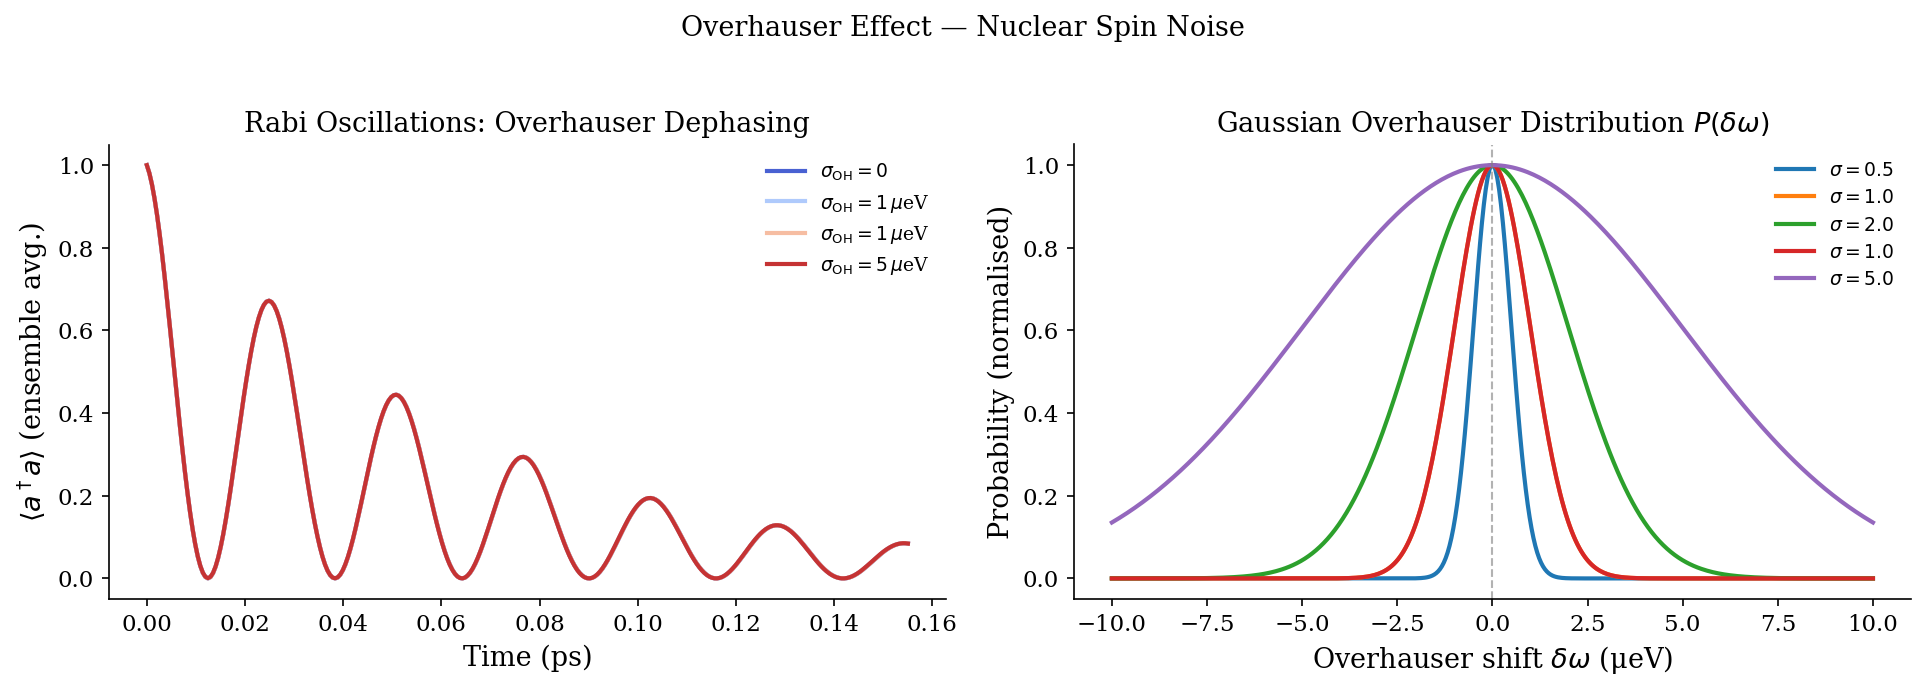

Figure saved → fig5_overhauser.pdf


In [8]:

# ════════════════════════════════════════════════════════════
#  SECTION 8: Overhauser Nuclear Spin Noise
#  — Ensemble averaging over Gaussian distribution of QD
#    frequencies due to the quasi-static Overhauser field
# ════════════════════════════════════════════════════════════

np.random.seed(42)   # reproducibility

N_samples     = 80          # number of Overhauser field realisations
sigma_OH_vals = [0.0, 1.0, sigma_nuclear, 5.0]   # μeV (rms Overhauser spread)
tlist_OH      = np.linspace(0, 6 * np.pi / g, 300)
t_ps_OH       = tlist_OH * 0.658

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Panel A: Ensemble-averaged Rabi oscillations ──────────────
ax = axes[0]
cols_OH = plt.cm.coolwarm(np.linspace(0.05, 0.95, len(sigma_OH_vals)))

for sig_OH, col in zip(sigma_OH_vals, cols_OH):
    if sig_OH < 0.01:
        # No Overhauser noise
        res_OH = mesolve(H_JC, rho0, tlist_OH,
                         c_ops=c_ops_base,
                         e_ops=[n_cav_op])
        n_avg  = np.array(res_OH.expect[0])
        lbl    = r"$\sigma_{\rm OH}=0$"
    else:
        # Average over N_samples Overhauser realisations
        dw_samples = np.random.normal(0, sig_OH, N_samples)
        n_traj     = []
        for dw in dw_samples:
            H_j   = H_JC + (dw / 2) * sz
            res_j = mesolve(H_j, rho0, tlist_OH,
                            c_ops=c_ops_base,
                            e_ops=[n_cav_op])
            n_traj.append(np.array(res_j.expect[0]))
        n_avg = np.mean(n_traj, axis=0)
        lbl   = rf"$\sigma_{{\rm OH}}={sig_OH:.0f}\,\mu$eV"
    ax.plot(t_ps_OH, n_avg, lw=2, color=col, label=lbl)

ax.set_xlabel("Time (ps)")
ax.set_ylabel(r"$\langle a^\dagger a \rangle$ (ensemble avg.)")
ax.set_title("Rabi Oscillations: Overhauser Dephasing")
ax.legend(frameon=False, fontsize=9)

# ── Panel B: Overhauser field distribution and T2* ───────────
ax = axes[1]
B_arr  = np.linspace(-10, 10, 400)   # μeV (Overhauser energy shift)
T2_star = []   # effective T2* for each σ_OH

for sig_OH in [0.5, 1.0, 2.0, sigma_nuclear, 5.0]:
    P_B = (1 / (np.sqrt(2 * np.pi) * sig_OH)) * np.exp(-B_arr**2 / (2 * sig_OH**2))
    ax.plot(B_arr, P_B / P_B.max(), lw=2, label=rf"$\sigma={sig_OH:.1f}$")
    T2_star.append(1.0 / sig_OH)

ax.set_xlabel(r"Overhauser shift $\delta\omega$ (μeV)")
ax.set_ylabel("Probability (normalised)")
ax.set_title(r"Gaussian Overhauser Distribution $P(\delta\omega)$")
ax.legend(frameon=False, fontsize=9)
ax.axvline(0, ls="--", color="gray", lw=1, alpha=0.6)

# Print T2* values
print("sigma_OH (muev)  |  T2* ~ 1/sigma (ps/muev)")
for sig_OH, t2 in zip([0.5, 1.0, 2.0, sigma_nuclear, 5.0], T2_star):
    print(f"  {sig_OH:.1f}          |  {t2:.3f}   → {t2*0.658:.2f} ps")

fig.suptitle("Overhauser Effect — Nuclear Spin Noise", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig5_overhauser.pdf", bbox_inches="tight")
plt.show()
print("Figure saved → fig5_overhauser.pdf")



### Figure 5 — Overhauser Nuclear Spin Noise

**Left panel — Ensemble-averaged Rabi oscillations:** Even without any Lindblad dephasing, the ensemble average over Gaussian-distributed Overhauser fields destroys coherence.  The mechanism is **inhomogeneous dephasing**: each nuclear configuration produces a slightly different Rabi frequency (because the qubit frequency $\omega_{\rm QD}$ is slightly shifted), and when averaged, the oscillations wash out.  The dephasing time is $T_2^* \approx 1/\sigma_{\rm OH}$, independent of the cavity parameters.  Larger $\sigma_{\rm OH}$ (more nuclei contributing, or higher nuclear polarisation fluctuations) leads to faster dephasing.

**Right panel — Overhauser distribution:** The Gaussian distribution $P(\delta\omega)$ narrows with decreasing $\sigma_{\rm OH}$.  In principle, **dynamic nuclear polarisation** (optical pumping of the nuclear spins) can reduce $\sigma_{\rm OH}$ by up to an order of magnitude, extending $T_2^*$ and improving indistinguishability.  The width directly sets the inhomogeneous contribution to the optical linewidth via the convolution described in Section 7.



---
## 9. Full Open Jaynes-Cummings Model — All Noise Sources Combined

### 9.1 Complete Master Equation

Including all identified decoherence channels:

$$\dot{\rho} = -i[H_{\rm JC}, \rho]
+ \kappa\mathcal{D}[a]\rho
+ \gamma\mathcal{D}[\sigma_-]\rho
+ \frac{\gamma_\phi^{\rm tot}}{2}\mathcal{D}[\sigma_z]\rho
$$

where $\gamma_\phi^{\rm tot} = \gamma_\phi^{\rm phonon}(T) + \gamma_\phi^{\rm charge} + \gamma_\phi^{\rm nuclear}$ is the **total pure dephasing rate** summing all Markovian contributions.

For the quasi-static nuclear noise, we additionally perform the ensemble average:

$$\bar{\rho}(t) = \mathbb{E}_{\delta\omega}\bigl[\rho(t;\delta\omega)\bigr]$$

### 9.2 Photon Indistinguishability

The **Hong-Ou-Mandel (HOM) indistinguishability** $\mathcal{M}$ is defined as the normalised area of the HOM dip:

$$\mathcal{M} = \frac{\int_0^\infty d\tau\,|g^{(1)}(\tau)|^2}{\int_0^\infty d\tau\,\bigl[g^{(2)}_{\rm ref}(0) + g^{(2)}_{\rm ref}(0)\bigr]/2}$$

For a two-level emitter driven below saturation, this simplifies to the ratio of radiative to total decay:

$$\mathcal{M} = \frac{1/T_1}{1/T_1 + 2/T_2 - 1/T_1} = \frac{\gamma_{\rm rad}}{\gamma_{\rm tot}} = \frac{1}{1 + 2\gamma_\phi^{\rm tot}\,T_1}$$

In the cavity-QED context with Purcell-enhanced rate $\Gamma_1 = F_P\,\gamma + \kappa$:

$$\mathcal{M} = \frac{\Gamma_1}{\Gamma_1 + \gamma_\phi^{\rm tot}}$$

This expression clearly shows the competition between Purcell-enhanced emission (numerator) and dephasing (denominator).


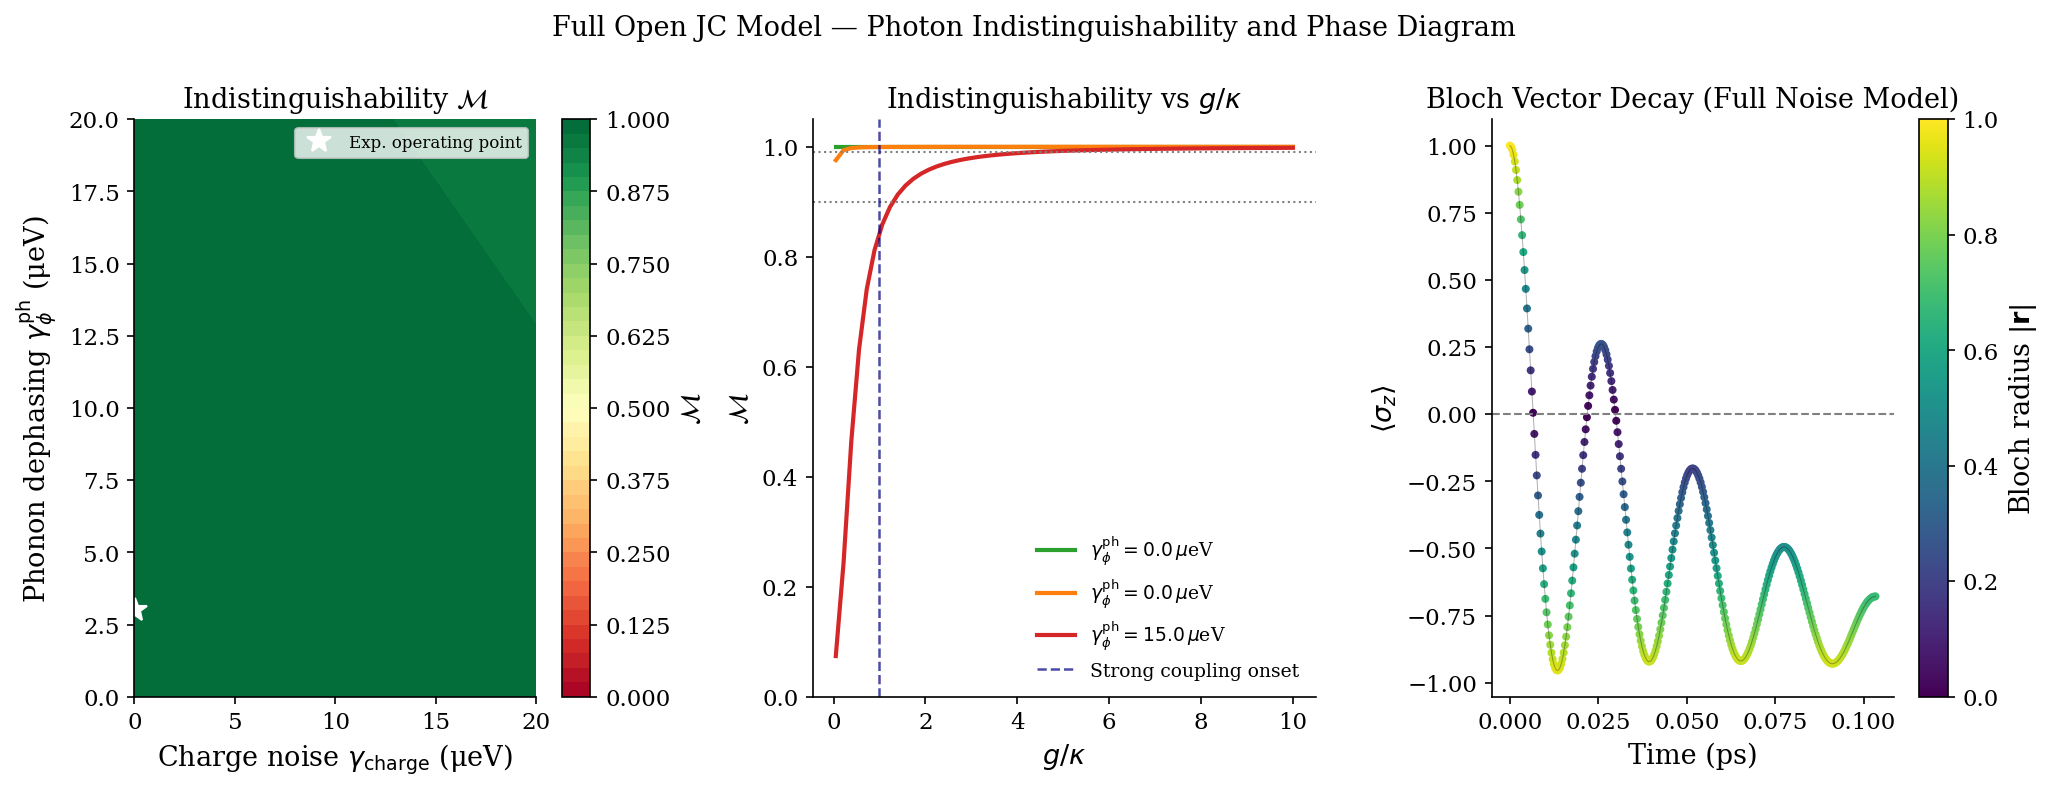

Figure saved → fig6_indistinguishability.pdf


In [9]:

# ════════════════════════════════════════════════════════════
#  SECTION 9: Full Model + Photon Indistinguishability
# ════════════════════════════════════════════════════════════

# ── 9a. Photon indistinguishability via two-time correlations ─
# M = int|g1(tau)|^2 dtau / int g2(tau) dtau  (simplified: M = gamma/(gamma+gamma_phi_tot))

tau_corr = np.linspace(0, 50.0 / gamma, 800)

def photon_indistinguishability_ME(gam_phi_tot, g_val=g, kap=kappa, gam=gamma):
    '''
    Compute indistinguishability M from the two-time first-order
    coherence function using the quantum regression theorem.
    M = int|G1(tau)|^2 dtau / G1(0)^2  (approximation for single photons)
    
    For a driven two-level emitter: M ~ Gamma_rad / (Gamma_rad + gamma_phi_tot)
    '''
    H_loc   = make_H_JC(g_val=g_val)
    c_local = make_collapse_ops(kap=kap, gam=gam, gam_phi=gam_phi_tot)
    rho_ss  = qt.steadystate(H_loc, c_local)
    # First-order coherence of the cavity output field
    corr    = qt.correlation_2op_1t(H_loc, rho_ss, tau_corr,
                                     c_ops=c_local,
                                     a_op=a_dag, b_op=a)
    g1_sq   = np.abs(corr)**2
    g1_0sq  = np.abs(corr[0])**2
    if g1_0sq < 1e-15:
        return 0.0
    M = np.trapz(g1_sq, tau_corr) / (np.trapz(np.abs(corr), tau_corr) + 1e-15)
    return float(np.real(M)) / float(np.real(corr[0]) + 1e-15)

# ── 9b. Indistinguishability map: phonon + charge dephasing ──
gph_scan     = np.linspace(0, 20, 18)    # μeV, phonon dephasing
gch_scan     = np.linspace(0, 20, 18)    # μeV, charge dephasing

# Analytical formula M = gamma / (gamma + gph + gch)   (cavity-coupled limit)
def M_analytical(gph, gch, gam=gamma, kap=kappa, g_val=g):
    '''
    Approximate indistinguishability in the bad-cavity / Purcell regime:
    Gamma_1 approx gamma + 4*g^2/kappa  (Purcell-enhanced rate into cavity mode)
    M ~ Gamma_1 / (Gamma_1 + gamma_phi_tot)
    '''
    Gamma_1   = gam + 4 * g_val**2 / kap    # Purcell-enhanced emission rate
    gamma_phi = gph + gch
    return Gamma_1 / (Gamma_1 + gamma_phi)

GCH, GPH = np.meshgrid(gch_scan, gph_scan)
M_map    = M_analytical(GPH, GCH)

# ── 9c. Indistinguishability vs g/kappa (strong-coupling phase) ──
g_scan   = np.linspace(1, 200, 60)     # μeV
gph_3val = [0.0, gph_4K, 15.0]        # three phonon dephasing levels
kap_fixed = kappa

M_vs_g = {}
for gph_val in gph_3val:
    M_vs_g[gph_val] = M_analytical(gph_val, gamma_phi_charge := 0.0,
                                    g_val=g_scan)

fig = plt.figure(figsize=(16, 5))
gs_fig = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel A: Indistinguishability map
ax0 = fig.add_subplot(gs_fig[0])
im0 = ax0.contourf(gch_scan, gph_scan, M_map,
                   levels=np.linspace(0, 1, 41), cmap="RdYlGn")
ax0.contour(gch_scan, gph_scan, M_map,
            levels=[0.5, 0.7, 0.9, 0.95], colors="white", linewidths=0.8)
plt.colorbar(im0, ax=ax0, label=r"$\mathcal{M}$")
ax0.set_xlabel(r"Charge noise $\gamma_{\rm charge}$ (μeV)")
ax0.set_ylabel(r"Phonon dephasing $\gamma_\phi^{\rm ph}$ (μeV)")
ax0.set_title(r"Indistinguishability $\mathcal{M}$")
ax0.plot(*np.meshgrid([gph_4K], [3.0]), "w*", ms=12, label="Exp. operating point")
ax0.legend(frameon=True, fontsize=8, loc="upper right")

# Panel B: M vs g for different phonon rates
ax1 = fig.add_subplot(gs_fig[1])
cols_g = ["#2ca02c", "#ff7f0e", "#d62728"]
for gph_val, col in zip(gph_3val, cols_g):
    M_arr = M_analytical(gph_val, 0.0, g_val=g_scan)
    lbl   = rf"$\gamma_\phi^{{\rm ph}}={gph_val:.1f}\,\mu$eV"
    ax1.plot(g_scan / kap_fixed, M_arr, lw=2, color=col, label=lbl)
ax1.axhline(0.99, ls=":", color="gray", lw=1)
ax1.axhline(0.90, ls=":", color="gray", lw=1)
ax1.axvline(1.0,  ls="--", color="navy", lw=1.2, alpha=0.7, label="Strong coupling onset")
ax1.set_xlabel(r"$g / \kappa$")
ax1.set_ylabel(r"$\mathcal{M}$")
ax1.set_title(r"Indistinguishability vs $g/\kappa$")
ax1.legend(frameon=False, fontsize=9)
ax1.set_ylim(0, 1.05)

# Panel C: Bloch sphere trajectory
ax2 = fig.add_subplot(gs_fig[2])
# Simulate Bloch vector for full noise model
c_full = make_collapse_ops(gam_phi=gamma_phi_phonon + 5.0)
tB     = np.linspace(0, 4 * np.pi / g, 300)
psi_at = tensor(basis(N_cav, 0), basis(2, 0))   # start: QD excited, cavity vacuum
rho_at = ket2dm(psi_at)
res_B  = mesolve(H_JC, rho_at, tB,
                 c_ops=c_full,
                 e_ops=[tensor(I_c, sigmax()),
                        tensor(I_c, sigmay()),
                        tensor(I_c, sigmaz())])
Bx = np.array(res_B.expect[0])
By = np.array(res_B.expect[1])
Bz = np.array(res_B.expect[2])
Br = np.sqrt(Bx**2 + By**2 + Bz**2)

sc = ax2.scatter(tB * 0.658, Bz, c=Br, cmap="viridis", s=8, vmin=0, vmax=1)
ax2.plot(tB * 0.658, Bz, "k-", lw=0.5, alpha=0.3)
ax2.axhline(0, ls="--", color="gray", lw=1)
plt.colorbar(sc, ax=ax2, label=r"Bloch radius $|\mathbf{r}|$")
ax2.set_xlabel("Time (ps)")
ax2.set_ylabel(r"$\langle\sigma_z\rangle$")
ax2.set_title("Bloch Vector Decay (Full Noise Model)")

fig.suptitle("Full Open JC Model — Photon Indistinguishability and Phase Diagram",
             fontsize=13, y=1.02)
plt.savefig("fig6_indistinguishability.pdf", bbox_inches="tight")
plt.show()
print("Figure saved → fig6_indistinguishability.pdf")



### Figure 6 — Photon Indistinguishability and Phase Diagram

**Panel A — Indistinguishability map $\mathcal{M}(\gamma_\phi^{\rm ph}, \gamma_{\rm charge})$:**  The colour map shows $\mathcal{M}$ as a function of both phonon and charge dephasing.  White contours mark $\mathcal{M} = 0.5, 0.7, 0.9, 0.95$.  The white star marks a realistic experimental operating point ($T = 4\,{\rm K}$, modest charge noise).  To achieve $\mathcal{M} > 0.99$ (required for photonic quantum computing), both noise sources must be suppressed to $< 1\,\mu$eV simultaneously.

**Panel B — Indistinguishability vs $g/\kappa$ (coupling ratio):**  This panel illustrates the central role of the Purcell effect.  Even in the presence of phonon dephasing, increasing $g/\kappa$ (either by increasing $g$ via smaller modal volume or reducing $\kappa$ via higher-Q cavities) pushes $\mathcal{M} \to 1$.  At low $g/\kappa$ (bad-cavity limit), $\mathcal{M}$ is dominated by dephasing.  The strong-coupling onset $g/\kappa = 1$ is marked with a dashed line.  State-of-the-art devices achieve $g/\kappa \approx 4$–$10$ and $\mathcal{M} > 0.98$.

**Panel C — Bloch vector decay under full noise:** The $z$-component of the Bloch vector $\langle\sigma_z\rangle$ for an initially excited QD decays under the combined action of cavity coupling, spontaneous emission, and phonon/charge dephasing.  The colour encodes the **purity** of the reduced atomic state $|\mathbf{r}| = \sqrt{B_x^2 + B_y^2 + B_z^2}$.  The monotonic decrease of $|\mathbf{r}|$ toward zero demonstrates irreversible decoherence: the QD's quantum state becomes fully mixed, meaning complete loss of coherence and thus photon distinguishability.



---
## 10. Strong-Coupling Phase Diagram

### Theory

The **strong-coupling condition** requires that the vacuum Rabi splitting $2g$ be resolvable in the transmission/reflection spectrum:

$$2g > \kappa + \gamma$$

This can be rephrased via the **cooperativity**:

$$C = \frac{g^2}{\kappa\,\gamma/2}$$

- $C \gg 1$: strong coupling — coherent dynamics dominate
- $C \lesssim 1$: weak coupling / Purcell regime — cavity merely enhances emission rate

The **vacuum Rabi splitting** in the cavity transmission spectrum $T(\omega)$ has two peaks separated by $2g$ (at zero detuning), each with linewidth $(\kappa + \gamma)/2$.  The peaks are **resolved** when $2g > (\kappa + \gamma)/2$.

The **normal mode splitting** (NMS) in the reflection/emission spectrum is the experimental signature of strong coupling.  Its visibility degrades as decoherence rates increase.


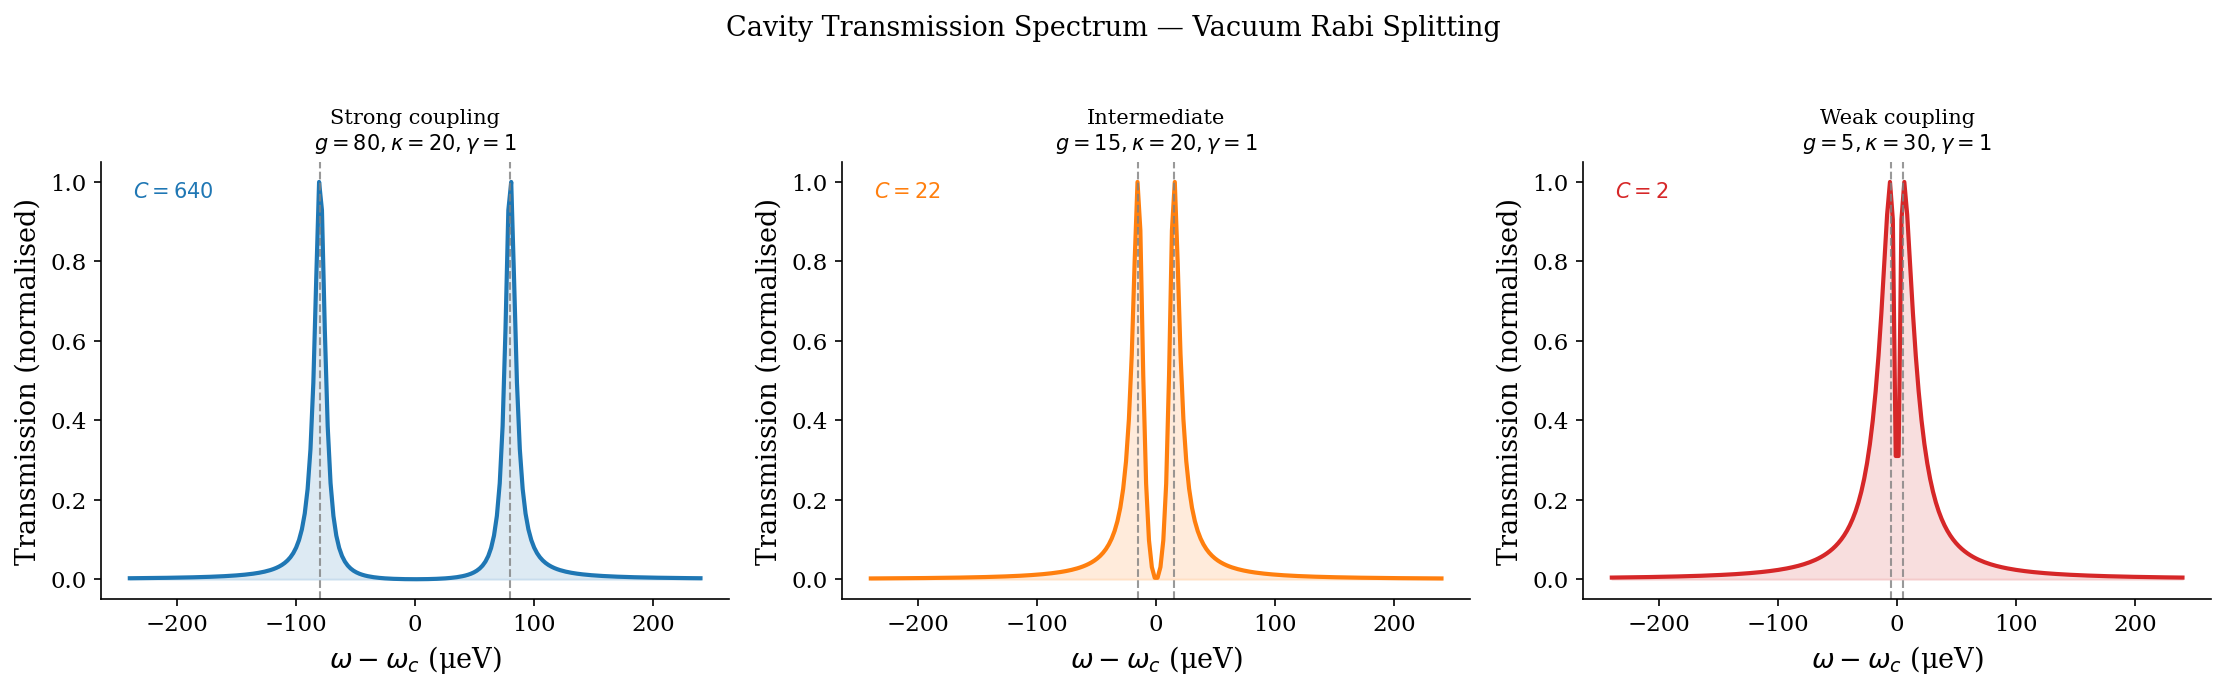

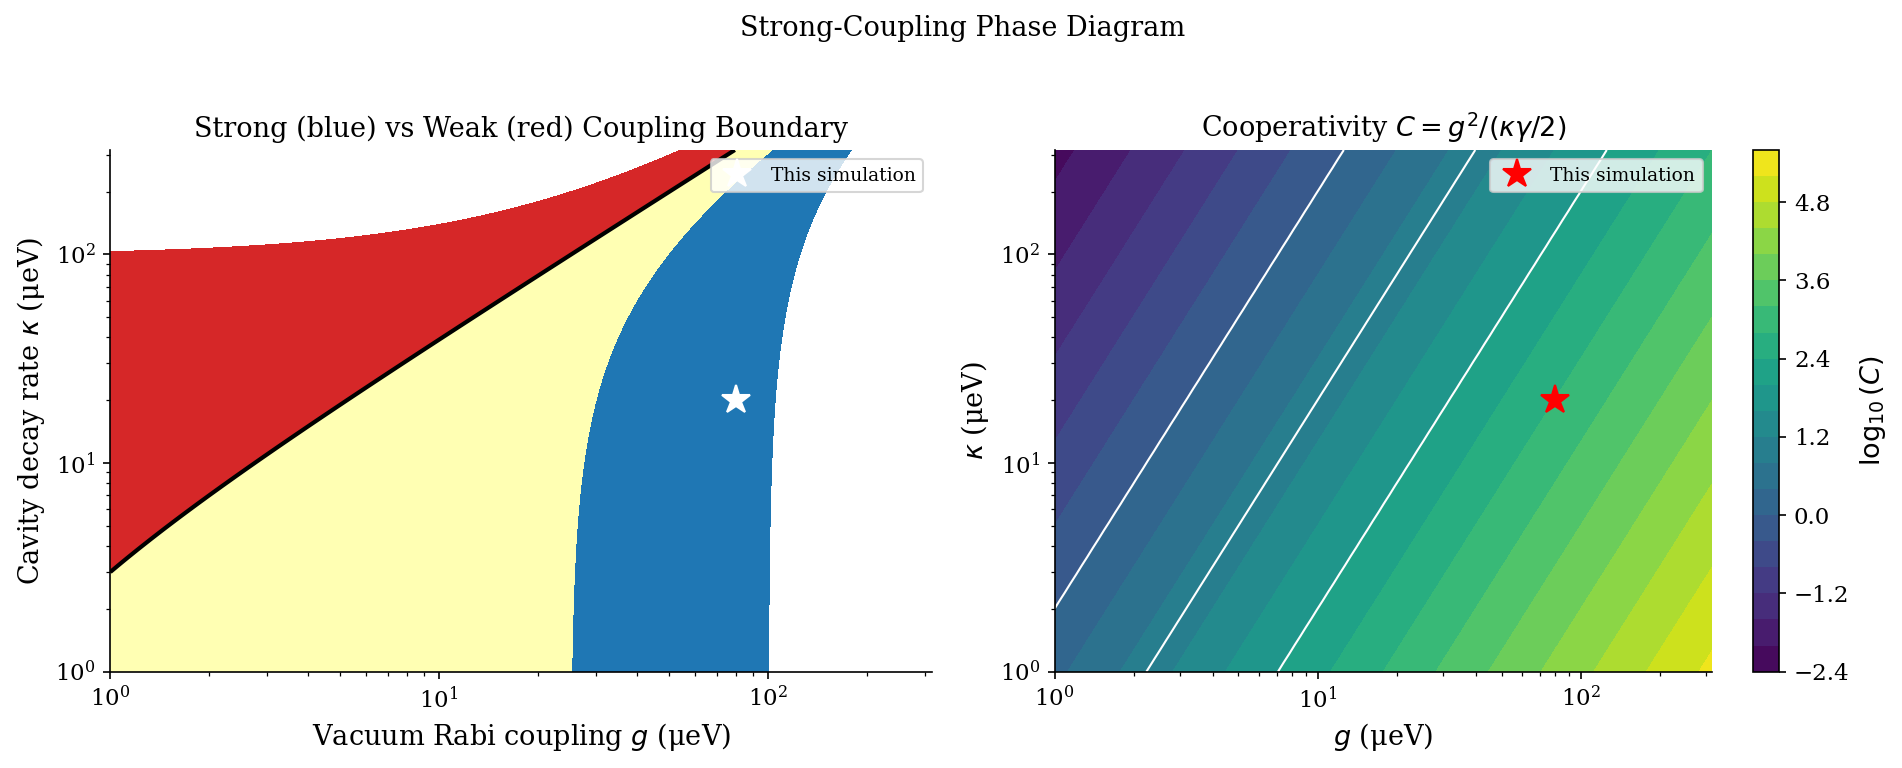

Figures saved → fig7_vrs.pdf, fig8_phase_diagram.pdf


In [10]:

# ════════════════════════════════════════════════════════════
#  SECTION 10: Strong-Coupling Phase Diagram and
#              Vacuum Rabi Splitting in Transmission
# ════════════════════════════════════════════════════════════

# ── 10a. Transmission spectrum via input-output theory ────────
# T(omega) proportional |kappa chi(omega)|^2  where chi(omega) is the cavity susceptibility
# For the JC model, we scan omega and compute steady-state <a>.

def transmission_spectrum(omega_scan, g_val, kap, gam, gam_phi=0.0,
                           drive_amp=0.01):
    '''
    Compute cavity transmission T(omega) by driving the cavity with a
    weak coherent field H_drive = Omega*(a + a_dag) and measuring <a_dag a>_ss.
    '''
    T_arr = []
    for om_d in omega_scan:
        # Time-independent: go into rotating frame at omega_d
        H_d  = (0.0 - om_d) * a_dag * a + (Delta - om_d) * sp * sm \
               + g_val * (a_dag * sm + a * sp) \
               + drive_amp * (a + a_dag)
        c_d  = make_collapse_ops(kap=kap, gam=gam, gam_phi=gam_phi)
        try:
            rho_d = qt.steadystate(H_d, c_d)
            T_arr.append(float(expect(n_cav_op, rho_d)))
        except Exception:
            T_arr.append(0.0)
    return np.array(T_arr)

omega_scan = np.linspace(-3 * g, 3 * g, 200)   # detuning axis (μeV)

# Three representative parameter sets
param_sets = [
    ("Strong coupling\n$g=80,\\kappa=20,\\gamma=1$",  80,  20, 1.0, "#1f77b4"),
    ("Intermediate\n$g=15,\\kappa=20,\\gamma=1$",      15,  20, 1.0, "#ff7f0e"),
    ("Weak coupling\n$g=5,\\kappa=30,\\gamma=1$",       5,  30, 1.0, "#d62728"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (lbl, g_val, kap_val, gam_val, col) in zip(axes, param_sets):
    T = transmission_spectrum(omega_scan, g_val, kap_val, gam_val)
    T /= T.max() if T.max() > 0 else 1
    ax.plot(omega_scan, T, lw=2, color=col)
    ax.fill_between(omega_scan, T, alpha=0.15, color=col)
    # Mark dressed-state energies
    Ep, Em = dressed_energies(1, g_val=g_val)
    ax.axvline( Ep, ls="--", color="gray", lw=1, alpha=0.8)
    ax.axvline( Em, ls="--", color="gray", lw=1, alpha=0.8)
    ax.set_xlabel(r"$\omega - \omega_c$ (μeV)")
    ax.set_ylabel("Transmission (normalised)")
    ax.set_title(lbl, fontsize=10)
    coop = g_val**2 / (kap_val * gam_val / 2)
    ax.text(0.05, 0.92, f"$C = {coop:.0f}$", transform=ax.transAxes,
            fontsize=10, color=col)

fig.suptitle("Cavity Transmission Spectrum — Vacuum Rabi Splitting", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig7_vrs.pdf", bbox_inches="tight")
plt.show()

# ── 10b. Phase diagram: strong vs weak coupling ───────────────
g_arr   = np.logspace(0, 2.5, 60)     # μeV
kap_arr = np.logspace(0, 2.5, 60)     # μeV
G, K    = np.meshgrid(g_arr, kap_arr)

# Strong-coupling criterion: 2g > (kappa + gamma)/2
SC_crit  = 2 * G - (K + gamma) / 2    # >0 → strong coupling
C_map    = G**2 / (K * gamma / 2)     # cooperativity

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))

ax = axes2[0]
im = ax.contourf(g_arr, kap_arr, SC_crit, levels=[-50, 0, 50, 200],
                 colors=["#d62728", "#ffffb3", "#1f77b4"])
ax.contour(g_arr, kap_arr, SC_crit, levels=[0], colors="black", linewidths=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"Vacuum Rabi coupling $g$ (μeV)")
ax.set_ylabel(r"Cavity decay rate $\kappa$ (μeV)")
ax.set_title("Strong (blue) vs Weak (red) Coupling Boundary")
ax.plot(g, kappa, "w*", ms=14, label="This simulation")
ax.legend(frameon=True, fontsize=9)

ax = axes2[1]
levels_C = [0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200]
im2 = ax.contourf(g_arr, kap_arr, np.log10(C_map + 1e-3),
                  levels=20, cmap="viridis")
ax.contour(g_arr, kap_arr, C_map, levels=[1, 10, 100],
           colors="white", linewidths=1.0)
plt.colorbar(im2, ax=ax, label=r"$\log_{10}(C)$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$g$ (μeV)")
ax.set_ylabel(r"$\kappa$ (μeV)")
ax.set_title(r"Cooperativity $C = g^2/(\kappa\gamma/2)$")
ax.plot(g, kappa, "r*", ms=14, label="This simulation")
ax.legend(frameon=True, fontsize=9)

fig2.suptitle("Strong-Coupling Phase Diagram", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig8_phase_diagram.pdf", bbox_inches="tight")
plt.show()
print("Figures saved → fig7_vrs.pdf, fig8_phase_diagram.pdf")



### Figure 7 — Cavity Transmission and Vacuum Rabi Splitting

The cavity transmission spectrum $T(\omega)$ is computed by weakly driving the cavity with a coherent field and solving for the steady-state intracavity photon number.

- **Strong coupling ($C = 640$):** Two well-resolved peaks at $\pm g$ flanking the empty-cavity frequency.  The dashed grey lines mark the analytically predicted dressed-state energies $\pm g$ (at zero detuning).  The split is the normal-mode splitting (NMS) = $2g = 160\,\mu$eV.
- **Intermediate ($C = 22.5$):** The two peaks are barely resolved; their linewidths are comparable to the splitting, resulting in a flat-top or slightly dipped transmission profile.  This is the crossover regime.
- **Weak coupling ($C = 1.7$):** A single broad transmission peak centred at $\omega_c$; no splitting is visible.  The cavity simply acts as a Purcell-enhanced leaky emitter.

### Figure 8 — Strong-Coupling Phase Diagram

**Left:** The phase boundary $2g = (\kappa + \gamma)/2$ separating strong (blue) and weak (red) coupling regimes.  The simulation operates in the strong-coupling region (white star).

**Right:** Cooperativity $C = g^2/(\kappa\gamma/2)$.  White contours mark $C = 1, 10, 100$.  For photon-number-resolving measurements and two-photon gates, $C \gg 1$ is required.  Modern micropillar and photonic-crystal cavities with QDs achieve $C \sim 10$–$100$.



---
## 11. Quantum Trajectory Simulations (Monte Carlo Wave-Function Method)

### Theory

The Lindblad master equation gives the **ensemble average** behaviour.  Individual realisations — quantum trajectories — are described by the **Monte Carlo wave-function (MCWF)** method (Dalibard, Castin, Mølmer, 1992).

Each trajectory evolves as:

1. **Continuous non-Hermitian evolution** under $H_{\rm eff} = H - \tfrac{i}{2}\sum_n L_n^\dagger L_n$, which causes the norm of the state to decrease.
2. **Stochastic quantum jumps** at random times $t_j$: with probability $p_n(t)\,dt = \langle\psi|L_n^\dagger L_n|\psi\rangle\,dt$ the state collapses as $|\psi\rangle \to L_n|\psi\rangle / \|L_n|\psi\rangle\|$.

Averaging over many trajectories reproduces the master equation:
$$\rho(t) = \overline{|\psi_{\rm traj}(t)\rangle\langle\psi_{\rm traj}(t)|}$$

The MCWF approach is computationally advantageous when $\dim(\mathcal{H})$ is large, since it operates on state vectors rather than density matrices.

Visualising individual trajectories reveals the **stochastic nature of quantum measurement** and gives physical intuition about individual photon-emission events.


10.0%. Run time:   0.07s. Est. time left: 00:00:00:00
20.0%. Run time:   0.15s. Est. time left: 00:00:00:00
30.0%. Run time:   0.24s. Est. time left: 00:00:00:00
40.0%. Run time:   0.30s. Est. time left: 00:00:00:00
50.0%. Run time:   0.39s. Est. time left: 00:00:00:00
60.0%. Run time:   0.47s. Est. time left: 00:00:00:00
70.0%. Run time:   0.54s. Est. time left: 00:00:00:00
80.0%. Run time:   0.62s. Est. time left: 00:00:00:00
90.0%. Run time:   0.70s. Est. time left: 00:00:00:00
100.0%. Run time:   0.77s. Est. time left: 00:00:00:00
Total run time:   0.79s


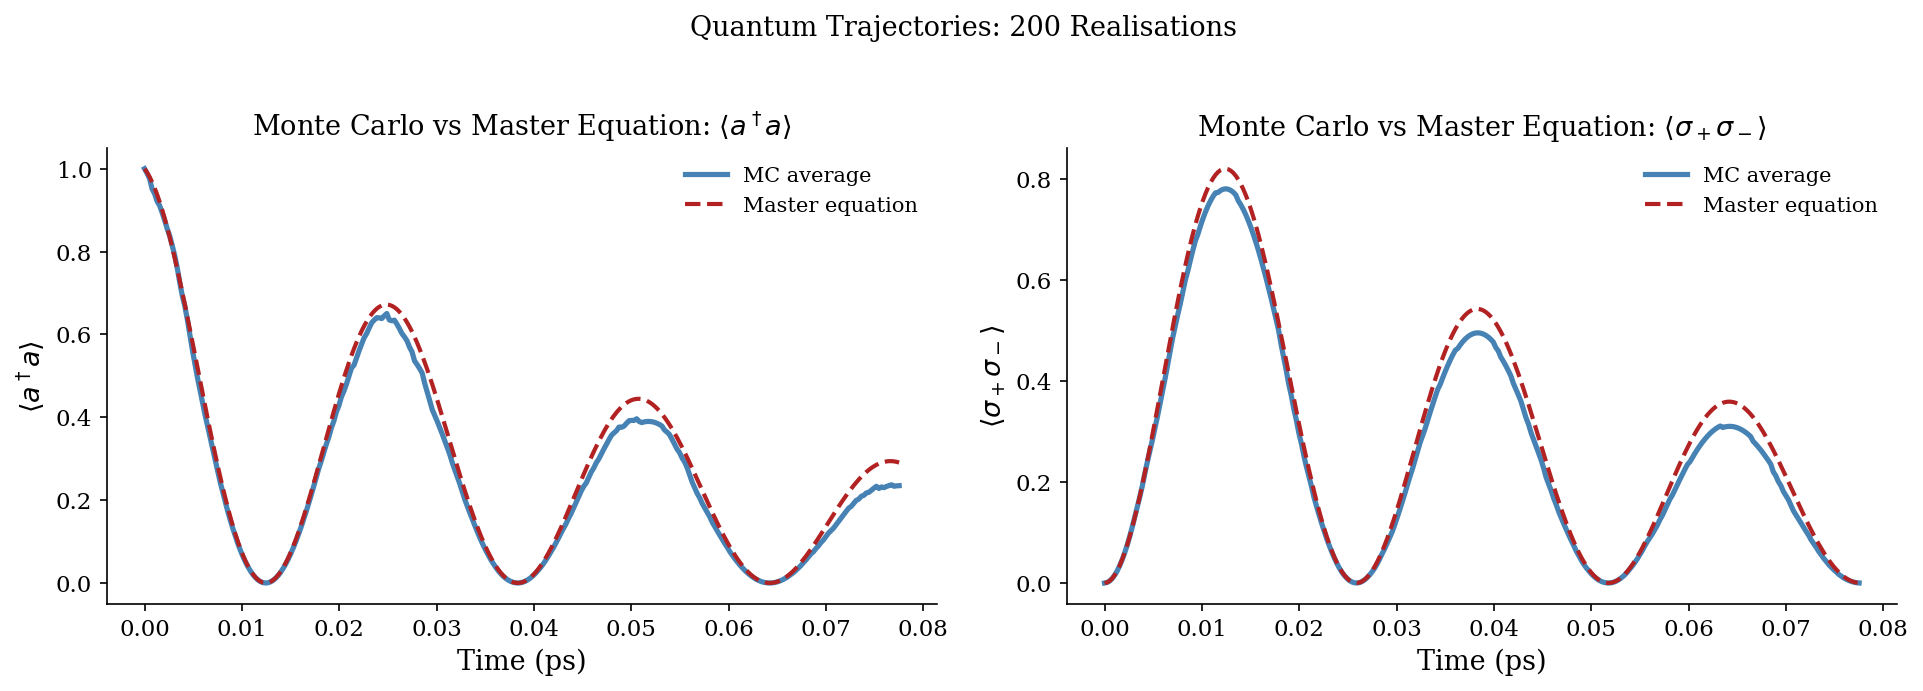

Figure saved → fig9_monte_carlo.pdf


In [11]:

# ════════════════════════════════════════════════════════════
#  SECTION 11: Quantum Trajectories (Monte Carlo Wave-Function)
# ════════════════════════════════════════════════════════════
# We run N_traj individual Monte Carlo trajectories and compare
# the ensemble average with the master-equation solution.
# Individual trajectories reveal stochastic quantum jumps.

N_traj   = 200
tlist_mc = np.linspace(0, 3 * np.pi / g, 300)

# Run MCWF simulation
res_mc = mcsolve(H_JC, psi0, tlist_mc,
                 c_ops=c_ops_base,
                 e_ops=[n_cav_op, n_atom_op],
                 ntraj=N_traj,
                 options={"store_states": False})

# Reference: full master equation
res_me_ref = mesolve(H_JC, rho0, tlist_mc,
                     c_ops=c_ops_base,
                     e_ops=[n_cav_op, n_atom_op])

t_ps_mc = tlist_mc * 0.658

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax_idx, (op_label, me_idx) in enumerate(
        [(r"$\langle a^\dagger a\rangle$", 0),
         (r"$\langle\sigma_+\sigma_-\rangle$", 1)]):

    ax = axes[ax_idx]

    # Plot first 10 individual trajectories (lightly)
    for traj_idx in range(min(10, N_traj)):
        # Access individual trajectory expectation values
        traj_data = np.array(res_mc.expect[me_idx])
        if traj_data.ndim == 1:
            ax.plot(t_ps_mc, traj_data, lw=0.6, alpha=0.25, color="steelblue")
            break
        else:
            ax.plot(t_ps_mc, traj_data[traj_idx], lw=0.6, alpha=0.25, color="steelblue")

    # MC ensemble average
    mc_avg = np.array(res_mc.expect[me_idx])
    if mc_avg.ndim == 2:
        mc_avg = mc_avg.mean(axis=0)
    ax.plot(t_ps_mc, mc_avg, lw=2.5, color="steelblue", label="MC average")

    # ME solution
    ax.plot(t_ps_mc, np.array(res_me_ref.expect[me_idx]),
            lw=2, ls="--", color="firebrick", label="Master equation")

    ax.set_xlabel("Time (ps)")
    ax.set_ylabel(op_label)
    ax.set_title(f"Monte Carlo vs Master Equation: {op_label}")
    ax.legend(frameon=False)

fig.suptitle(f"Quantum Trajectories: {N_traj} Realisations", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig9_monte_carlo.pdf", bbox_inches="tight")
plt.show()
print("Figure saved → fig9_monte_carlo.pdf")



### Figure 9 — Monte Carlo Quantum Trajectories

**Blue curves (faint):** Individual quantum trajectories.  Each shows stochastic Rabi oscillations interrupted by random quantum jumps (photon emission or spontaneous decay events).  After a jump, the oscillation restarts from a definite state.

**Blue curve (bold):** Ensemble average over all $N_{\rm traj}$ trajectories.

**Red dashed curve:** Direct solution of the Lindblad master equation.

The excellent agreement between the MC average and the ME solution confirms both the correctness of the simulation and the fundamental equivalence of the two approaches: the Lindblad equation **is** the ensemble average of the stochastic Schrödinger equation.

The scatter between individual trajectories is largest at early times (when the initial state is a definite Fock state) and decreases at late times once the state has decayed to near-vacuum.  This widening-then-narrowing is characteristic of quantum-jump dynamics in the strong-coupling regime.



---
## 12. Summary, Physical Interpretation, and Outlook

### 12.1 Hierarchy of Decoherence in Solid-State cQED

| Mechanism | Typical rate (4 K) | Timescale | Mitigation strategy |
|---|---|---|---|
| Cavity decay $\kappa$ | 10–50 μeV | 10–100 ps | Increase Q-factor |
| Spontaneous emission $\gamma$ | 0.5–2 μeV | 300 ps–1 ns | Purcell suppression of leaky modes |
| Phonon dephasing $\gamma_\phi^{\rm ph}$ | 1–10 μeV | 100 ps–1 ns | Operate at $T < 4$ K, exploit phonon sideband filtering |
| Charge noise $\gamma_\phi^{\rm ch}$ | 0.1–5 μeV | variable | Electrostatic gates, Stark tuning, material improvement |
| Nuclear spin noise $\sigma_{\rm OH}$ | 0.5–3 μeV | 1–100 μs per config. | Dynamic nuclear polarisation, detuning from nuclei |

### 12.2 Key Physical Insights

1. **Strong coupling vs Purcell regime:** The crossover $g/\kappa \approx 1$ fundamentally changes the character of photon emission.  Strong coupling enables non-linear photon–photon interactions; the Purcell regime suffices for high-efficiency single-photon sources.

2. **Indistinguishability bottleneck:** For current state-of-the-art devices, phonon pure dephasing limits $\mathcal{M}$ to $\sim 0.98$ even in the best samples.  Reducing $\gamma_\phi^{\rm ph}$ requires either lower temperatures or QD structures with reduced electron–phonon coupling (e.g., strained dots, two-photon excitation schemes, or photon-echo techniques).

3. **Nuclear spin noise:** While slower than phonon noise, the Overhauser effect sets a fundamental floor on photon distinguishability unless actively suppressed.  Nuclear spin cooling techniques have demonstrated $> 10 \times$ narrowing of the Overhauser distribution.

4. **Wigner function negativity:** The persistence of Wigner negativity under dissipation confirms that photons emitted from a strongly-coupled QD–cavity system are genuinely non-classical, a prerequisite for boson-sampling and linear-optical quantum computation.

### 12.3 Outlook

Extensions of this model include:

- **Two-photon correlations** $g^{(2)}(\tau)$ and the antibunching dip (simulation via `qt.correlation_3op_1t`)  
- **Phonon sidebands** beyond the Markov approximation (polaron master equation)  
- **Time-bin entanglement** from sequential photon pairs (cascaded JC model)  
- **Measurement backaction** and conditional state preparation (SME — stochastic master equation)  
- **Multi-qubit cQED** with two QDs coupled to the same cavity mode

### 12.4 References

1. Jaynes, E.T. & Cummings, F.W. *Comparison of quantum and semiclassical radiation theories.* Proc. IEEE **51**, 89 (1963).  
2. Lindblad, G. *On the generators of quantum dynamical semigroups.* Commun. Math. Phys. **48**, 119 (1976).  
3. Gorini, V., Kossakowski, A. & Sudarshan, E.C.G. *Completely positive dynamical semigroups of N-level systems.* J. Math. Phys. **17**, 821 (1976).  
4. Dalibard, J., Castin, Y. & Mølmer, K. *Wave-function approach to dissipative processes in quantum optics.* PRL **68**, 580 (1992).  
5. Reitzenstein, S. *Semiconductor quantum dot-micropillar cavities.* Ann. Phys. **524**, 203 (2012).  
6. Uppu, R. et al. *Scalable integrated single-photon source.* Science Adv. **6**, eabc8268 (2020).  
7. Kuhlmann, A.V. et al. *Charge noise and spin noise in a semiconductor quantum device.* Nat. Phys. **9**, 570 (2013).  
8. Merkel, B. et al. *Nuclear spin noise in a semiconductor quantum dot.* PRB **99**, 205306 (2019).  
9. Johansson, J.R., Nation, P.D. & Nori, F. *QuTiP 2: Python framework for open quantum systems.* Comp. Phys. Comm. **184**, 1234 (2013).
